## Imports

In [1]:
# Biblioteca padrão
import json
import os
import time
import hashlib
from datetime import datetime
from pathlib import Path

# Dados
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, RobustScaler, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# PySpark
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.window import Window

sns.set_style('whitegrid')
plt.rcParams.update({'figure.dpi': 120})
print('Imports carregados.')


Imports carregados.


## Ingestão

In [2]:
df_incidents = pd.read_csv('data/raw/incidents_master.csv')
df_market = pd.read_csv('data/raw/market_impact.csv')
df_financials = pd.read_csv('data/raw/financial_impact.csv')

In [3]:
df_incidents.head()

,incident_id,company_name,company_revenue_usd,country_hq,industry_primary,industry_secondary,employee_count,is_public_company,stock_ticker,incident_date,...,data_source_primary,data_source_secondary,data_source_type,confidence_tier,quality_score,quality_grade,review_flag,notes,created_at,updated_at
0,2021-0508-001,Quantum Asset Assurance Group Inc.,1.343769e+09,US,52,54,3940,True,QAA,2021-05-08,...,https://www.sec.gov/cgi-bin/browse-edgar?actio...,https://www.quantum-asset-assurance-g.com/news...,sec_filing,1,97.89,Gold,NaN,Multiple subsidiaries affected across 6 jurisd...,2026-02-12T10:00:00Z,2026-02-12T10:00:00Z
1,2025-1211-001,Quantum Apex Ventures Ltd.,6.367059e+07,GB,51,NaN,250,False,NaN,2025-12-11,...,https://www.theregister.com/2025/06/14/quantum...,https://blog.talosintelligence.com/2025/09/qua...,verified_media,3,86.74,Gold,NaN,NaN,2026-02-12T10:00:00Z,2026-02-12T10:00:00Z
2,2023-0115-001,BitWire Innovations Corp.,2.480619e+10,US,51,NaN,71369,True,BITW,2023-01-15,...,https://therecord.media/2023/12/10/bitwire-inn...,https://blog.talosintelligence.com/2023/08/bit...,verified_media,4,83.74,Silver,NaN,NaN,2026-02-12T10:00:00Z,2026-02-12T10:00:00Z
3,2021-0315-001,Sterling Forge Markets Holdings Inc.,1.398259e+08,US,44-45,NaN,912,True,SFM,2021-03-15,...,https://www.sterling-forge-markets-ho.com/news...,https://www.mandiant.com/resources/blog/sterli...,company_pr,2,94.51,Gold,NaN,NaN,2026-02-12T10:00:00Z,2026-02-12T10:00:00Z
4,2021-1204-001,Sierra Quantum Innovations Group Inc.,6.916977e+08,US,51,NaN,1662,True,SQI,2021-12-04,...,https://www.sierra-quantum-innovation.com/news...,NaN,company_pr,2,79.82,Silver,NaN,NaN,2026-02-12T10:00:00Z,2026-02-12T10:00:00Z


In [4]:
df_financials.head()

,incident_id,direct_loss_usd,direct_loss_method,ransom_demanded_usd,ransom_paid_usd,ransom_source,recovery_cost_usd,legal_fees_usd,regulatory_fine_usd,insurance_payout_usd,total_loss_usd,total_loss_method,total_loss_lower_bound,total_loss_upper_bound,inflation_adjusted_usd,cpi_index_used,notes,created_at,updated_at
0,2021-0508-001,12600000.00,disclosed,13802654.69,NaN,NaN,9455354.49,2496545.93,90695.25,6756288.97,24642595.67,calculated,15348190.29,4.374658e+07,29237902.75,CPI-U 2021 (270.97),NaN,2026-02-12T10:00:00Z,2026-02-12T10:00:00Z
1,2025-1211-001,7640471.18,disclosed,NaN,NaN,NaN,5857150.47,1809188.41,NaN,2691027.33,15306810.06,disclosed,10206030.81,1.890634e+07,15306810.06,CPI-U 2025 (321.5),NaN,2026-02-12T10:00:00Z,2026-02-12T10:00:00Z
2,2023-0115-001,34881599.59,calculated,NaN,NaN,NaN,26404111.95,10330703.43,NaN,31759649.99,71616414.97,disclosed,60854299.98,1.051520e+08,75564575.92,CPI-U 2023 (304.702),NaN,2026-02-12T10:00:00Z,2026-02-12T10:00:00Z
3,2021-0315-001,4682151.47,disclosed,NaN,NaN,NaN,3642946.48,1029035.85,NaN,1772460.33,9354133.80,disclosed,7648967.81,1.452521e+07,11098475.91,CPI-U 2021 (270.97),NaN,2026-02-12T10:00:00Z,2026-02-12T10:00:00Z
4,2021-1204-001,2684607.92,estimated,NaN,NaN,NaN,2574871.33,206822.23,NaN,NaN,5466301.48,estimated,3519806.28,6.755823e+06,6485647.58,CPI-U 2021 (270.97),NaN,2026-02-12T10:00:00Z,2026-02-12T10:00:00Z


In [5]:
df_market.head()

,incident_id,stock_ticker,price_7d_before,price_disclosure_day,price_1d_after,price_7d_after,price_30d_after,volume_avg_30d_baseline,volume_disclosure_day,sector_index,...,p_value_30d,earnings_announcement_within_7d,market_cap_at_disclosure,volume_ratio_disclosure,pre_incident_volatility_30d,post_incident_volatility_30d,days_to_price_recovery,notes,created_at,updated_at
0,2023-0115-001,BITW,262.07,251.95,245.11,250.34,246.87,19782288,48767234,S&P 500 Information Technology,...,1.00000,True,1.181988e+11,2.4652,0.027705,0.052161,255.0,NaN,2026-02-12T10:00:00Z,2026-02-12T10:00:00Z
1,2021-0315-001,SFM,9.37,9.09,8.73,8.78,8.67,458826,1421143,S&P 500 Consumer Discretionary,...,0.98240,False,6.489114e+08,3.0973,0.017116,0.027638,324.0,NaN,2026-02-12T10:00:00Z,2026-02-12T10:00:00Z
2,2021-1204-001,SQI,14.60,13.36,13.09,13.28,13.17,230932,354433,S&P 500 Information Technology,...,1.00000,False,4.735164e+09,1.5348,0.038209,0.045756,19.0,NaN,2026-02-12T10:00:00Z,2026-02-12T10:00:00Z
3,2021-0213-001,STUT.DE,5.34,5.43,5.27,5.36,5.37,2521343,6491913,S&P 500 Consumer Discretionary,...,1.00000,False,2.984412e+09,2.5748,0.027980,0.030972,24.0,NaN,2026-02-12T10:00:00Z,2026-02-12T10:00:00Z
4,2025-0529-001,BAZA,465.19,441.08,410.45,428.36,429.49,1235984,3250371,S&P 500 Consumer Discretionary,...,0.38875,False,2.194296e+11,2.6298,0.025212,0.038232,313.0,NaN,2026-02-12T10:00:00Z,2026-02-12T10:00:00Z


In [6]:
print(df_incidents.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 850 entries, 0 to 849
Data columns (total 32 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   incident_id               850 non-null    object 
 1   company_name              850 non-null    object 
 2   company_revenue_usd       850 non-null    float64
 3   country_hq                850 non-null    object 
 4   industry_primary          850 non-null    object 
 5   industry_secondary        153 non-null    object 
 6   employee_count            850 non-null    int64  
 7   is_public_company         850 non-null    bool   
 8   stock_ticker              412 non-null    object 
 9   incident_date             850 non-null    object 
 10  incident_date_estimated   850 non-null    bool   
 11  discovery_date            850 non-null    object 
 12  disclosure_date           850 non-null    object 
 13  attack_vector_primary     850 non-null    object 
 14  attack_vec

In [7]:
print(df_market.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 358 entries, 0 to 357
Data columns (total 31 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   incident_id                      358 non-null    object 
 1   stock_ticker                     358 non-null    object 
 2   price_7d_before                  358 non-null    float64
 3   price_disclosure_day             358 non-null    float64
 4   price_1d_after                   358 non-null    float64
 5   price_7d_after                   358 non-null    float64
 6   price_30d_after                  358 non-null    float64
 7   volume_avg_30d_baseline          358 non-null    int64  
 8   volume_disclosure_day            358 non-null    int64  
 9   sector_index                     358 non-null    object 
 10  sector_return_same_period        358 non-null    float64
 11  abnormal_return_1d               358 non-null    float64
 12  abnormal_return_7d    

In [8]:
print(df_financials.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 778 entries, 0 to 777
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   incident_id             778 non-null    object 
 1   direct_loss_usd         778 non-null    float64
 2   direct_loss_method      778 non-null    object 
 3   ransom_demanded_usd     206 non-null    float64
 4   ransom_paid_usd         86 non-null     float64
 5   ransom_source           86 non-null     object 
 6   recovery_cost_usd       778 non-null    float64
 7   legal_fees_usd          778 non-null    float64
 8   regulatory_fine_usd     132 non-null    float64
 9   insurance_payout_usd    435 non-null    float64
 10  total_loss_usd          778 non-null    float64
 11  total_loss_method       778 non-null    object 
 12  total_loss_lower_bound  778 non-null    float64
 13  total_loss_upper_bound  778 non-null    float64
 14  inflation_adjusted_usd  778 non-null    fl

In [9]:
print(df_incidents.isna().sum())

incident_id                   0
company_name                  0
company_revenue_usd           0
country_hq                    0
industry_primary              0
industry_secondary          697
employee_count                0
is_public_company             0
stock_ticker                438
incident_date                 0
incident_date_estimated       0
discovery_date                0
disclosure_date               0
attack_vector_primary         0
attack_vector_secondary     639
attack_chain                275
attributed_group            368
attribution_confidence      368
data_compromised_records    248
data_type                   248
systems_affected              0
downtime_hours              430
data_source_primary           0
data_source_secondary       464
data_source_type              0
confidence_tier               0
quality_score                 0
quality_grade                 0
review_flag                 780
notes                       636
created_at                    0
updated_

In [10]:
print(df_market.isna().sum())

incident_id                          0
stock_ticker                         0
price_7d_before                      0
price_disclosure_day                 0
price_1d_after                       0
price_7d_after                       0
price_30d_after                      0
volume_avg_30d_baseline              0
volume_disclosure_day                0
sector_index                         0
sector_return_same_period            0
abnormal_return_1d                   0
abnormal_return_7d                   0
abnormal_return_30d                  0
car_neg1_to_pos1                     0
car_0_to_7                           0
car_0_to_30                          0
car_0_to_90                          0
t_statistic_1d                       0
p_value_1d                           0
t_statistic_30d                      0
p_value_30d                          0
earnings_announcement_within_7d      0
market_cap_at_disclosure             0
volume_ratio_disclosure              0
pre_incident_volatility_3

In [11]:
print(df_financials.isna().sum())

incident_id                 0
direct_loss_usd             0
direct_loss_method          0
ransom_demanded_usd       572
ransom_paid_usd           692
ransom_source             692
recovery_cost_usd           0
legal_fees_usd              0
regulatory_fine_usd       646
insurance_payout_usd      343
total_loss_usd              0
total_loss_method           0
total_loss_lower_bound      0
total_loss_upper_bound      0
inflation_adjusted_usd      0
cpi_index_used              0
notes                     530
created_at                  0
updated_at                  0
dtype: int64


### Metadados de ingestão

In [12]:
df_incidents['_ingestion_timestamp'] = datetime.now().strftime('%Y-%m-%d')
df_market['_ingestion_timestamp'] = datetime.now().strftime('%Y-%m-%d')
df_financials['_ingestion_timestamp'] = datetime.now().strftime('%Y-%m-%d')

## Conversão de tipos

In [13]:
# Datas
for col in ['incident_date', 'discovery_date', 'disclosure_date', '_ingestion_timestamp']:
    df_incidents[col] = pd.to_datetime(df_incidents[col], errors='coerce')

df_market['_ingestion_timestamp'] = pd.to_datetime(df_market['_ingestion_timestamp'], errors='coerce')

df_financials['_ingestion_timestamp'] = pd.to_datetime(df_financials['_ingestion_timestamp'], errors='coerce')

# created_at e updated_at têm fuso
df_incidents['created_at'] = pd.to_datetime(df_incidents['created_at'], utc=True, errors='coerce')
df_incidents['updated_at']  = pd.to_datetime(df_incidents['updated_at'],  utc=True, errors='coerce')

df_market['created_at'] = pd.to_datetime(df_market['created_at'], utc=True, errors='coerce')
df_market['updated_at']  = pd.to_datetime(df_market['updated_at'],  utc=True, errors='coerce')

df_financials['created_at'] = pd.to_datetime(df_financials['created_at'], utc=True, errors='coerce')
df_financials['updated_at']  = pd.to_datetime(df_financials['updated_at'],  utc=True, errors='coerce')

print("Tipos após conversão:")
print('--'*15, 'Incidents', '--'*15)
print(df_incidents[['incident_date', 'discovery_date', 'disclosure_date', '_ingestion_timestamp', 'created_at', 'updated_at']].dtypes)
print('--'*15, 'Market', '--'*15)
print(df_market[['_ingestion_timestamp', 'created_at', 'updated_at']].dtypes)
print('--'*15, 'Financials', '--'*15)
print(df_financials[['_ingestion_timestamp', 'created_at', 'updated_at']].dtypes)

Tipos após conversão:
------------------------------ Incidents ------------------------------
incident_date                datetime64[ns]
discovery_date               datetime64[ns]
disclosure_date              datetime64[ns]
_ingestion_timestamp         datetime64[ns]
created_at              datetime64[ns, UTC]
updated_at              datetime64[ns, UTC]
dtype: object
------------------------------ Market ------------------------------
_ingestion_timestamp         datetime64[ns]
created_at              datetime64[ns, UTC]
updated_at              datetime64[ns, UTC]
dtype: object
------------------------------ Financials ------------------------------
_ingestion_timestamp         datetime64[ns]
created_at              datetime64[ns, UTC]
updated_at              datetime64[ns, UTC]
dtype: object


## Persistência

In [14]:
Path('data/bronze').mkdir(parents=True, exist_ok=True)

df_incidents.to_parquet('./data/bronze/bronze_incidents.parquet')
df_market.to_parquet('./data/bronze/bronze_market.parquet')
df_financials.to_parquet('./data/bronze/bronze_financials.parquet')

In [15]:
#tamanho dataset original em bits
print('Tamanho do dataset  incidents original em bits: ' + str(Path('data/raw/incidents_master.csv').stat().st_size))
print('Tamanho do dataset  market original em bits: ' + str(Path('data/raw/market_impact.csv').stat().st_size))
print('Tamanho do dataset  financials original em bits: ' + str(Path('data/raw/financial_impact.csv').stat().st_size))
print('---------------------------------------------------------')
print('Tamanho do bronze_incidents em bits: ' + str(Path('data/bronze/bronze_incidents.parquet').stat().st_size))
print('Tamanho do bronze_financials em bits: ' + str(Path('data/bronze/bronze_financials.parquet').stat().st_size))
print('Tamanho do bronze_market em bits: ' + str(Path('data/bronze/bronze_market.parquet').stat().st_size))

Tamanho do dataset  incidents original em bits: 438941
Tamanho do dataset  market original em bits: 109318
Tamanho do dataset  financials original em bits: 170578
---------------------------------------------------------
Tamanho do bronze_incidents em bits: 132912
Tamanho do bronze_financials em bits: 74898
Tamanho do bronze_market em bits: 92005


In [16]:
df_bronze_incidents = pd.read_parquet('./data/bronze/bronze_incidents.parquet')
df_bronze_market = pd.read_parquet('./data/bronze/bronze_market.parquet')
df_bronze_financials = pd.read_parquet('./data/bronze/bronze_financials.parquet')

### Verificando nulos

In [17]:
def print_nulos(df):
    missing=pd.DataFrame(df.isnull().sum(),columns=["Null Values"])
    missing["% Missing Values"]=(df.isna().sum()/len(df)*100)
    missing = missing[missing["% Missing Values"] > 0].sort_values(by="% Missing Values", ascending=False)
    print(missing.head(100))

In [18]:
print('bronze_incidents')
print_nulos(df_bronze_incidents)

print('\n--------\nbronze_market')
print_nulos(df_bronze_market)

print('\n--------\nbronze_financials')
print_nulos(df_bronze_financials)


bronze_incidents
                          Null Values  % Missing Values
review_flag                       780         91.764706
industry_secondary                697         82.000000
attack_vector_secondary           639         75.176471
notes                             636         74.823529
data_source_secondary             464         54.588235
stock_ticker                      438         51.529412
downtime_hours                    430         50.588235
attribution_confidence            368         43.294118
attributed_group                  368         43.294118
attack_chain                      275         32.352941
data_type                         248         29.176471
data_compromised_records          248         29.176471

--------
bronze_market
                        Null Values  % Missing Values
notes                           266         74.301676
days_to_price_recovery           36         10.055866

--------
bronze_financials
                      Null Values  % Miss

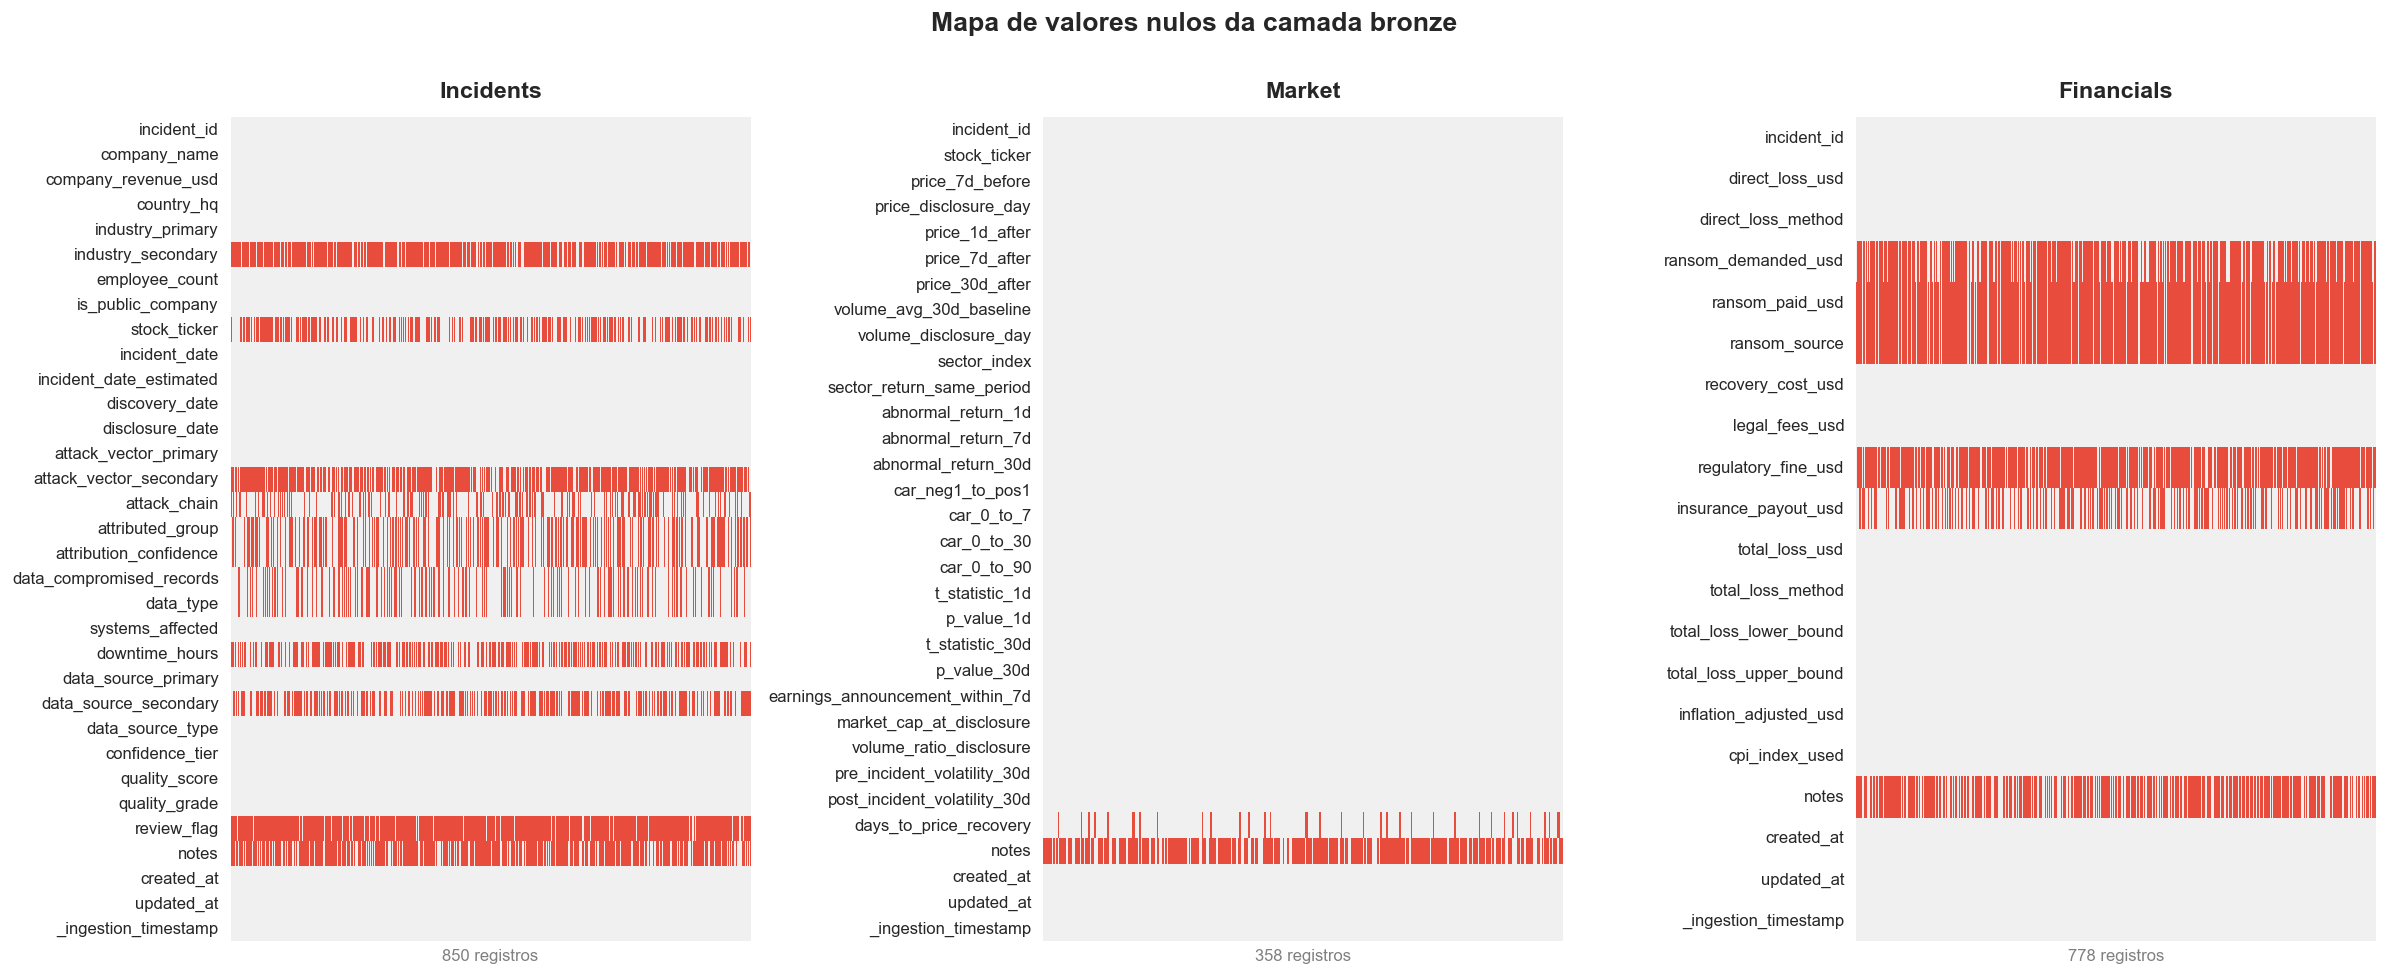

In [19]:
# Visualizacao do mapa de nulos
fig, axes = plt.subplots(1, 3, figsize=(20,8))

datasets = {
    "Incidents": df_bronze_incidents,
    "Market": df_bronze_market,
    "Financials": df_bronze_financials,
}

for ax, (title, df) in zip(axes, datasets.items()):
    sns.heatmap(
        df.isnull().T,
        cmap=['#F0F0F0','#E74C3C'],
        cbar=False, 
        ax=ax, 
        xticklabels=False, 
        yticklabels=True
    )
    ax.set_title(title, fontsize=14, fontweight="bold", pad=12)
    ax.set_xlabel(f"{len(df):,} registros", fontsize=10, color="gray")
    ax.set_ylabel("")

fig.suptitle("Mapa de valores nulos da camada bronze", fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

## Buscando duplicatas

In [20]:
datasets = [df_bronze_incidents, df_bronze_market, df_bronze_financials]

for df in datasets:
    print(df[df.duplicated()])

Empty DataFrame
Columns: [incident_id, company_name, company_revenue_usd, country_hq, industry_primary, industry_secondary, employee_count, is_public_company, stock_ticker, incident_date, incident_date_estimated, discovery_date, disclosure_date, attack_vector_primary, attack_vector_secondary, attack_chain, attributed_group, attribution_confidence, data_compromised_records, data_type, systems_affected, downtime_hours, data_source_primary, data_source_secondary, data_source_type, confidence_tier, quality_score, quality_grade, review_flag, notes, created_at, updated_at, _ingestion_timestamp]
Index: []

[0 rows x 33 columns]
Empty DataFrame
Columns: [incident_id, stock_ticker, price_7d_before, price_disclosure_day, price_1d_after, price_7d_after, price_30d_after, volume_avg_30d_baseline, volume_disclosure_day, sector_index, sector_return_same_period, abnormal_return_1d, abnormal_return_7d, abnormal_return_30d, car_neg1_to_pos1, car_0_to_7, car_0_to_30, car_0_to_90, t_statistic_1d, p_value_

In [21]:
datasets = [df_bronze_incidents, df_bronze_market, df_bronze_financials]

for df in datasets:
    print(df[df.duplicated(subset=['incident_id'])])


Empty DataFrame
Columns: [incident_id, company_name, company_revenue_usd, country_hq, industry_primary, industry_secondary, employee_count, is_public_company, stock_ticker, incident_date, incident_date_estimated, discovery_date, disclosure_date, attack_vector_primary, attack_vector_secondary, attack_chain, attributed_group, attribution_confidence, data_compromised_records, data_type, systems_affected, downtime_hours, data_source_primary, data_source_secondary, data_source_type, confidence_tier, quality_score, quality_grade, review_flag, notes, created_at, updated_at, _ingestion_timestamp]
Index: []

[0 rows x 33 columns]
Empty DataFrame
Columns: [incident_id, stock_ticker, price_7d_before, price_disclosure_day, price_1d_after, price_7d_after, price_30d_after, volume_avg_30d_baseline, volume_disclosure_day, sector_index, sector_return_same_period, abnormal_return_1d, abnormal_return_7d, abnormal_return_30d, car_neg1_to_pos1, car_0_to_7, car_0_to_30, car_0_to_90, t_statistic_1d, p_value_

## Metadados de Ingestão — Bronze


In [22]:

lista_metadados = []

for item in ['data/raw/incidents_master.csv', 'data/raw/market_impact.csv', 'data/raw/financial_impact.csv']:

    arquivo = Path(item)

    # Hash SHA-256 do arquivo original
    sha256 = hashlib.sha256(arquivo.read_bytes()).hexdigest()

    metadata_bronze = {
        'arquivo': arquivo.name,
        'linhas': len(df),
        'colunas': len(df.columns),
        'tamanho_bytes': arquivo.stat().st_size,
        'hash_sha256': sha256,
        'data_carga': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
        'camada': 'bronze'
    }

    lista_metadados.append(metadata_bronze)

    print(json.dumps(metadata_bronze, indent=2))

# Salvar metadados em JSON ao lado do parquet
Path('data/bronze').mkdir(parents=True, exist_ok=True)
with open('data/bronze/metadata_bronze.json', 'w') as f:
    json.dump(lista_metadados, f, indent=2)

print('\nMetadados salvos em data/bronze/metadata_bronze.json')


{
  "arquivo": "incidents_master.csv",
  "linhas": 778,
  "colunas": 20,
  "tamanho_bytes": 438941,
  "hash_sha256": "9819d9ad6baeadca4c503d1146def6504da32e42b9e14e38b0008b24ffc84225",
  "data_carga": "2026-06-08 13:42:44",
  "camada": "bronze"
}
{
  "arquivo": "market_impact.csv",
  "linhas": 778,
  "colunas": 20,
  "tamanho_bytes": 109318,
  "hash_sha256": "d7f4ef0645bbc50f9e4cd159800f1f3f69f87fb5a9d0489f987f1ebc0fb827c1",
  "data_carga": "2026-06-08 13:42:44",
  "camada": "bronze"
}
{
  "arquivo": "financial_impact.csv",
  "linhas": 778,
  "colunas": 20,
  "tamanho_bytes": 170578,
  "hash_sha256": "9e375eb6f35b70d40166ae03e62cfe809d3e976bb9951498e6f5f2ce78b46679",
  "data_carga": "2026-06-08 13:42:44",
  "camada": "bronze"
}

Metadados salvos em data/bronze/metadata_bronze.json


## Relatório de Qualidade dos Dados — Bronze


In [23]:
def gerar_relatorio_qualidade(df, nome_camada='bronze'):
    total_linhas = len(df)
    duplicatas_totais = df.duplicated().sum()

    def classificar_status(pct):
        if pct > 50:   return 'CRITICO - >50% nulos'
        if pct > 20:   return 'ATENCAO - >20% nulos'
        return 'OK'

    relatorio = [
        {
            'coluna':    col,
            'tipo':      str(df[col].dtype),
            'nulos':     (nulos := df[col].isnull().sum()),
            'pct_nulo':  round(nulos / total_linhas * 100, 2),
            'duplicados': df[col].duplicated().sum() if df[col].dtype == 'object' else None,
            'status':    classificar_status(nulos / total_linhas * 100),
        }
        for col in df.columns
    ]

    df_rel = pd.DataFrame(relatorio)

    sep = '=' * 52
    print(f'\n{sep}')
    print(f'  Relatório de Qualidade — Camada {nome_camada.upper()}')
    print(sep)
    print(f'  Total de linhas  : {total_linhas:,}')
    print(f'  Linhas duplicadas: {duplicatas_totais:,}')
    print(f'{sep}\n')
    print(df_rel[['coluna', 'tipo', 'nulos', 'pct_nulo', 'status']].to_string(index=False))
    print()

    return df_rel


datasets = {
    'incidents':  df_bronze_incidents,
    'market':     df_bronze_market,
    'financials': df_bronze_financials,
}

relatorios = {
    nome: gerar_relatorio_qualidade(df, 'bronze')
    for nome, df in datasets.items()
}

for nome, df_rel in relatorios.items():
    df_rel.to_csv(f'data/bronze/relatorio_qualidade_bronze_{nome}.csv', index=False)


  Relatório de Qualidade — Camada BRONZE
  Total de linhas  : 850
  Linhas duplicadas: 0

                  coluna                tipo  nulos  pct_nulo               status
             incident_id              object      0      0.00                   OK
            company_name              object      0      0.00                   OK
     company_revenue_usd             float64      0      0.00                   OK
              country_hq              object      0      0.00                   OK
        industry_primary              object      0      0.00                   OK
      industry_secondary              object    697     82.00 CRITICO - >50% nulos
          employee_count               int64      0      0.00                   OK
       is_public_company                bool      0      0.00                   OK
            stock_ticker              object    438     51.53 CRITICO - >50% nulos
           incident_date      datetime64[ns]      0      0.00                  

---
# Camada Silver


## Ingestão 

In [24]:
df_silver_incidents = df_bronze_incidents.copy()
df_silver_market = df_bronze_market.copy()
df_silver_financials = df_bronze_financials.copy()

## Limpeza, Tratamento de Datas e Padronização

### Removendo linhas totalmente duplicadas

In [25]:
df_silver_incidents = df_bronze_incidents.drop_duplicates()
df_silver_market = df_bronze_market.drop_duplicates()
df_silver_financials = df_bronze_financials.drop_duplicates()

### Diagnóstico inicial após remoção de duplicatas

In [26]:
print(f"incidents  — shape: {df_silver_incidents.shape},  duplicatas removidas: {df_bronze_incidents.duplicated().sum()}")
print(f"market     — shape: {df_silver_market.shape},  duplicatas removidas: {df_bronze_market.duplicated().sum()}")
print(f"financials — shape: {df_silver_financials.shape},  duplicatas removidas: {df_bronze_financials.duplicated().sum()}")


incidents  — shape: (850, 33),  duplicatas removidas: 0
market     — shape: (358, 32),  duplicatas removidas: 0
financials — shape: (778, 20),  duplicatas removidas: 0


### Remoção de colunas sem impacto para ML

In [27]:
for df in [df_silver_incidents, df_silver_market, df_silver_financials]:
    df.drop(columns='notes', inplace=True)

### Padronização de colunas categóricas — incidents

Aplicamos `lower().strip()` para eliminar inconsistências de capitalização. `data_type` tinha valores como `'PII'` e `'IP'` em maiúsculas.

In [28]:
cols_cat_incidents = [
    'attack_vector_primary', 'attack_vector_secondary',
    'country_hq', 'data_type', 'attribution_confidence',
    'data_source_type', 'quality_grade'
]
for col in cols_cat_incidents:
    df_silver_incidents[col] = df_silver_incidents[col].str.lower().str.strip()

print("Valores únicos — attack_vector_primary:", df_silver_incidents['attack_vector_primary'].unique().tolist())
print("Valores únicos — data_type:            ", df_silver_incidents['data_type'].unique().tolist())
print("Valores únicos — country_hq (amostra): ", df_silver_incidents['country_hq'].unique()[:8].tolist())


Valores únicos — attack_vector_primary: ['ransomware', 'phishing', 'trojan', 'data_breach', 'apt', 'ddos', 'supply_chain', 'malware', 'backdoor']
Valores únicos — data_type:             ['mixed', None, 'pii', 'health', 'credentials', 'financial', 'ip']
Valores únicos — country_hq (amostra):  ['us', 'gb', 'de', 'at', 'ca', 'au', 'fr', 'ch']


### Padronização de colunas categóricas — market

In [29]:
df_silver_market['sector_index'] = df_silver_market['sector_index'].str.strip()
print("Setores:", df_silver_market['sector_index'].unique().tolist())

Setores: ['S&P 500 Information Technology', 'S&P 500 Consumer Discretionary', 'S&P 500 Industrials', 'S&P 500 Financials', 'S&P 500', 'S&P 500 Health Care', 'S&P 500 Utilities', 'S&P 500 Real Estate', 'S&P 500 Communication Services', 'S&P 500 Energy']


### Padronização de colunas categóricas — financials

In [30]:
cols_cat_fin = ['direct_loss_method', 'total_loss_method', 'ransom_source']
for col in cols_cat_fin:
    df_silver_financials[col] = df_silver_financials[col].str.lower().str.strip()

print("direct_loss_method:", df_silver_financials['direct_loss_method'].unique().tolist())
print("total_loss_method: ", df_silver_financials['total_loss_method'].unique().tolist())


direct_loss_method: ['disclosed', 'calculated', 'estimated']
total_loss_method:  ['calculated', 'disclosed', 'estimated']


### Tratamento de nulos — incidents

Colunas opcionais recebem valores semânticos (`'desconhecido'`, `'nao_capital_aberto'`). Numéricas com ausência estrutural recebem `0`.

In [31]:
# Categóricas opcionais
df_silver_incidents['attack_vector_secondary']= df_silver_incidents['attack_vector_secondary'].fillna('desconhecido')
df_silver_incidents['attributed_group']= df_silver_incidents['attributed_group'].fillna('desconhecido')
df_silver_incidents['attribution_confidence']= df_silver_incidents['attribution_confidence'].fillna('desconhecido')
df_silver_incidents['data_type']= df_silver_incidents['data_type'].fillna('desconhecido')
df_silver_incidents['stock_ticker']= df_silver_incidents['stock_ticker'].fillna('nao_capital_aberto')
df_silver_incidents['industry_secondary']= df_silver_incidents['industry_secondary'].fillna('nao_informado')
df_silver_incidents['attack_chain']= df_silver_incidents['attack_chain'].fillna('nao_informado')
df_silver_incidents['data_source_secondary']= df_silver_incidents['data_source_secondary'].fillna('nao_informado')

# Numéricas com ausência estrutural (empresa sem inatividade ou sem registros comprometidos)
df_silver_incidents['downtime_hours']= df_silver_incidents['downtime_hours'].fillna(0)
df_silver_incidents['data_compromised_records']= df_silver_incidents['data_compromised_records'].fillna(0)

print("Nulos restantes em incidents:")
print(df_silver_incidents.isnull().sum()[df_silver_incidents.isnull().sum() > 0])


Nulos restantes em incidents:
review_flag    780
dtype: int64


### Tratamento de nulos — market

`days_to_price_recovery` nulo significa que o preço não se recuperou no período observado — substituímos por `-1` como sentinela já que `0` ficaria muito ambiguo.

In [32]:
df_silver_market['days_to_price_recovery'] = df_silver_market['days_to_price_recovery'].fillna(-1)

print("Nulos restantes em market:")
remaining = df_silver_market.isnull().sum()
print(remaining[remaining > 0] if remaining[remaining > 0].any() else "Nenhum nulo relevante.")


Nulos restantes em market:
Nenhum nulo relevante.


### Tratamento de nulos — financials

Colunas de resgate são nulas por design para incidentes sem envolvimento de ransomware — usamos `0` para distinguir de ausência de dado.

In [33]:
df_silver_financials['ransom_demanded_usd']  = df_silver_financials['ransom_demanded_usd'].fillna(0)
df_silver_financials['ransom_paid_usd']      = df_silver_financials['ransom_paid_usd'].fillna(0)
df_silver_financials['regulatory_fine_usd']  = df_silver_financials['regulatory_fine_usd'].fillna(0)
df_silver_financials['insurance_payout_usd'] = df_silver_financials['insurance_payout_usd'].fillna(0)
df_silver_financials['ransom_source']        = df_silver_financials['ransom_source'].fillna('nao_aplicavel')

print("Nulos restantes em financials:")
remaining = df_silver_financials.isnull().sum()
print(remaining[remaining > 0] if remaining[remaining > 0].any() else "Nenhum nulo relevante.")


Nulos restantes em financials:
Nenhum nulo relevante.


### Remoção de colunas com risco de Data Leakage

Colunas produzidas por revisão humana pós-análise ou que derivam diretamente do alvo não devem fazer parte do conjunto de features.

In [34]:
leakage_incidents = ['quality_score', 'quality_grade', 'confidence_tier', 'review_flag']
df_silver_incidents = df_silver_incidents.drop(columns=leakage_incidents)
print(f"incidents — removidas: {leakage_incidents} | shape: {df_silver_incidents.shape}")


incidents — removidas: ['quality_score', 'quality_grade', 'confidence_tier', 'review_flag'] | shape: (850, 28)


### Tabela Checklist Anti-Leakage

In [35]:
checklist_leakage = [
    {'dataset': 'incidents', 'coluna': 'quality_score',           'risco': 'ALTO',  'acao': 'REMOVIDA',              'justificativa': 'Score calculado pós-incidente — vaza informação do futuro'},
    {'dataset': 'incidents', 'coluna': 'quality_grade',           'risco': 'ALTO',  'acao': 'REMOVIDA',              'justificativa': 'Grade derivada do quality_score'},
    {'dataset': 'incidents', 'coluna': 'confidence_tier',         'risco': 'ALTO',  'acao': 'REMOVIDA',              'justificativa': 'Tier de confiança atribuído pós-análise'},
    {'dataset': 'incidents', 'coluna': 'review_flag',             'risco': 'ALTO',  'acao': 'REMOVIDA',              'justificativa': 'Flag de revisão manual — indisponível no momento do incidente'},
    {'dataset': 'incidents', 'coluna': 'disclosure_date',         'risco': 'MEDIO', 'acao': 'MANTIDA',               'justificativa': 'Usar apenas como feature temporal, não como proxy do target'},
    {'dataset': 'incidents', 'coluna': 'attribution_confidence',  'risco': 'BAIXO', 'acao': 'MANTIDA',               'justificativa': 'Informação disponível no momento; tratada como categórica'},
    {'dataset': 'incidents', 'coluna': 'data_compromised_records','risco': 'MEDIO', 'acao': 'USADA NO LABEL (excluir das features)', 'justificativa': 'Compõe o label _is_high_impact'},
    {'dataset': 'incidents', 'coluna': 'downtime_hours',          'risco': 'MEDIO', 'acao': 'USADA NO LABEL (excluir das features)', 'justificativa': 'Compõe o label _is_high_impact'},
    {'dataset': 'market',    'coluna': 'car_0_to_90',             'risco': 'MEDIO', 'acao': 'MANTIDA',               'justificativa': 'Retorno acumulado 90d — usar apenas para análise pós-evento'},
    {'dataset': 'market',    'coluna': 'days_to_price_recovery',  'risco': 'MEDIO', 'acao': 'MANTIDA',               'justificativa': 'Resultado pós-incidente — não usar como feature preditiva'},
    {'dataset': 'financials','coluna': 'total_loss_usd',          'risco': 'ALTO',  'acao': 'USADA NO LABEL (excluir das features)', 'justificativa': 'Compõe o label _is_severe_loss'},
]

df_leakage = pd.DataFrame(checklist_leakage)
print(df_leakage.to_string(index=False))

Path('data/silver').mkdir(parents=True, exist_ok=True)
df_leakage.to_csv('data/silver/checklist_anti_leakage.csv', index=False)
print('\nChecklist salvo em data/silver/checklist_anti_leakage.csv')


   dataset                   coluna risco                                  acao                                                 justificativa
 incidents            quality_score  ALTO                              REMOVIDA     Score calculado pós-incidente — vaza informação do futuro
 incidents            quality_grade  ALTO                              REMOVIDA                               Grade derivada do quality_score
 incidents          confidence_tier  ALTO                              REMOVIDA                       Tier de confiança atribuído pós-análise
 incidents              review_flag  ALTO                              REMOVIDA Flag de revisão manual — indisponível no momento do incidente
 incidents          disclosure_date MEDIO                               MANTIDA   Usar apenas como feature temporal, não como proxy do target
 incidents   attribution_confidence BAIXO                               MANTIDA     Informação disponível no momento; tratada como categórica
 incid

### Criação dos Labels para Machine Learning

- **incidents** → `_is_high_impact`: 1 se registros comprometidos > 100k **ou** downtime > 72h
- **financials** → `_is_severe_loss`: 1 se prejuízo total > mediana
- **market** → `_is_significant_drop`: 1 se retorno anormal em 30d < -5%

In [36]:
# Label incidents
df_silver_incidents['_is_high_impact'] = (
    (df_silver_incidents['data_compromised_records'] > 100_000) |
    (df_silver_incidents['downtime_hours'] > 72)
).astype(int)

# Label financials
mediana_loss = df_silver_financials['total_loss_usd'].median()
df_silver_financials['_is_severe_loss'] = (
    df_silver_financials['total_loss_usd'] > mediana_loss
).astype(int)

# Label market
df_silver_market['_is_significant_drop'] = (
    df_silver_market['abnormal_return_30d'] < -0.05
).astype(int)

print("=== Distribuição dos Labels ===")
print(f"\n[incidents] _is_high_impact:")
print(df_silver_incidents['_is_high_impact'].value_counts().to_string())
print(f"  Proporção de alto impacto: {df_silver_incidents['_is_high_impact'].mean():.2%}")

print(f"\n[financials] _is_severe_loss  (mediana = R$ {mediana_loss:,.0f}):")
print(df_silver_financials['_is_severe_loss'].value_counts().to_string())
print(f"  Proporção de perda severa: {df_silver_financials['_is_severe_loss'].mean():.2%}")

print(f"\n[market] _is_significant_drop (retorno anormal 30d < -5%):")
print(df_silver_market['_is_significant_drop'].value_counts().to_string())
print(f"  Proporção de queda significativa: {df_silver_market['_is_significant_drop'].mean():.2%}")


=== Distribuição dos Labels ===

[incidents] _is_high_impact:
_is_high_impact
0    479
1    371
  Proporção de alto impacto: 43.65%

[financials] _is_severe_loss  (mediana = R$ 16,564,915):
_is_severe_loss
1    389
0    389
  Proporção de perda severa: 50.00%

[market] _is_significant_drop (retorno anormal 30d < -5%):
_is_significant_drop
0    329
1     29
  Proporção de queda significativa: 8.10%


### Documentação das Transformações Silver

In [37]:
transformacoes = [
    {'dataset': 'todos',       'etapa': '1', 'acao': 'Remoção de duplicatas',          'detalhes': 'drop_duplicates() — linhas 100% idênticas removidas'},
    {'dataset': 'todos',       'etapa': '2', 'acao': 'Padronização categórica',        'detalhes': 'str.lower().strip() em todas as colunas de texto categórico'},
    {'dataset': 'incidents',   'etapa': '3', 'acao': 'Preenchimento de nulos',         'detalhes': 'attack_vector_secondary, attributed_group, attribution_confidence, data_type → "desconhecido"; stock_ticker → "nao_capital_aberto"; downtime_hours, data_compromised_records → 0'},
    {'dataset': 'market',      'etapa': '3', 'acao': 'Preenchimento de nulos',         'detalhes': 'days_to_price_recovery → -1 (sentinela: preço não recuperado)'},
    {'dataset': 'financials',  'etapa': '3', 'acao': 'Preenchimento de nulos',         'detalhes': 'ransom_demanded/paid, regulatory_fine, insurance_payout → 0; ransom_source → "nao_aplicavel"'},
    {'dataset': 'incidents',   'etapa': '4', 'acao': 'Remoção anti-leakage',           'detalhes': 'quality_score, quality_grade, confidence_tier, review_flag removidas'},
    {'dataset': 'incidents',   'etapa': '5', 'acao': 'Label _is_high_impact',          'detalhes': '1 se data_compromised_records > 100k OU downtime_hours > 72'},
    {'dataset': 'financials',  'etapa': '5', 'acao': 'Label _is_severe_loss',          'detalhes': '1 se total_loss_usd > mediana do dataset'},
    {'dataset': 'market',      'etapa': '5', 'acao': 'Label _is_significant_drop',     'detalhes': '1 se abnormal_return_30d < -0.05 (queda anormal > 5%)'},
]

df_trans = pd.DataFrame(transformacoes)
print(df_trans.to_string(index=False))

df_trans.to_csv('data/silver/documentacao_transformacoes.csv', index=False)
print('\nDocumentação salva.')


   dataset etapa                       acao                                                                                                                                                                         detalhes
     todos     1      Remoção de duplicatas                                                                                                                              drop_duplicates() — linhas 100% idênticas removidas
     todos     2    Padronização categórica                                                                                                                      str.lower().strip() em todas as colunas de texto categórico
 incidents     3     Preenchimento de nulos attack_vector_secondary, attributed_group, attribution_confidence, data_type → "desconhecido"; stock_ticker → "nao_capital_aberto"; downtime_hours, data_compromised_records → 0
    market     3     Preenchimento de nulos                                                                         

### Salvando a Camada Silver

In [38]:
Path('data/silver').mkdir(parents=True, exist_ok=True)

df_silver_incidents.to_parquet('data/silver/silver_incidents.parquet', index=False)
df_silver_market.to_parquet('data/silver/silver_market.parquet', index=False)
df_silver_financials.to_parquet('data/silver/silver_financials.parquet', index=False)

for nome, df in [('incidents', df_silver_incidents), ('market', df_silver_market), ('financials', df_silver_financials)]:
    size = Path(f'data/silver/silver_{nome}.parquet').stat().st_size
    print(f"silver_{nome}.parquet | shape: {df.shape} | {size:,} bytes")


silver_incidents.parquet | shape: (850, 29) | 124,947 bytes
silver_market.parquet | shape: (358, 32) | 90,366 bytes
silver_financials.parquet | shape: (778, 20) | 72,869 bytes


---
## Análise Exploratória de Dados (EDA)

### Mapa de Nulos — Camada Silver

Confirmação visual de que os nulos foram tratados.

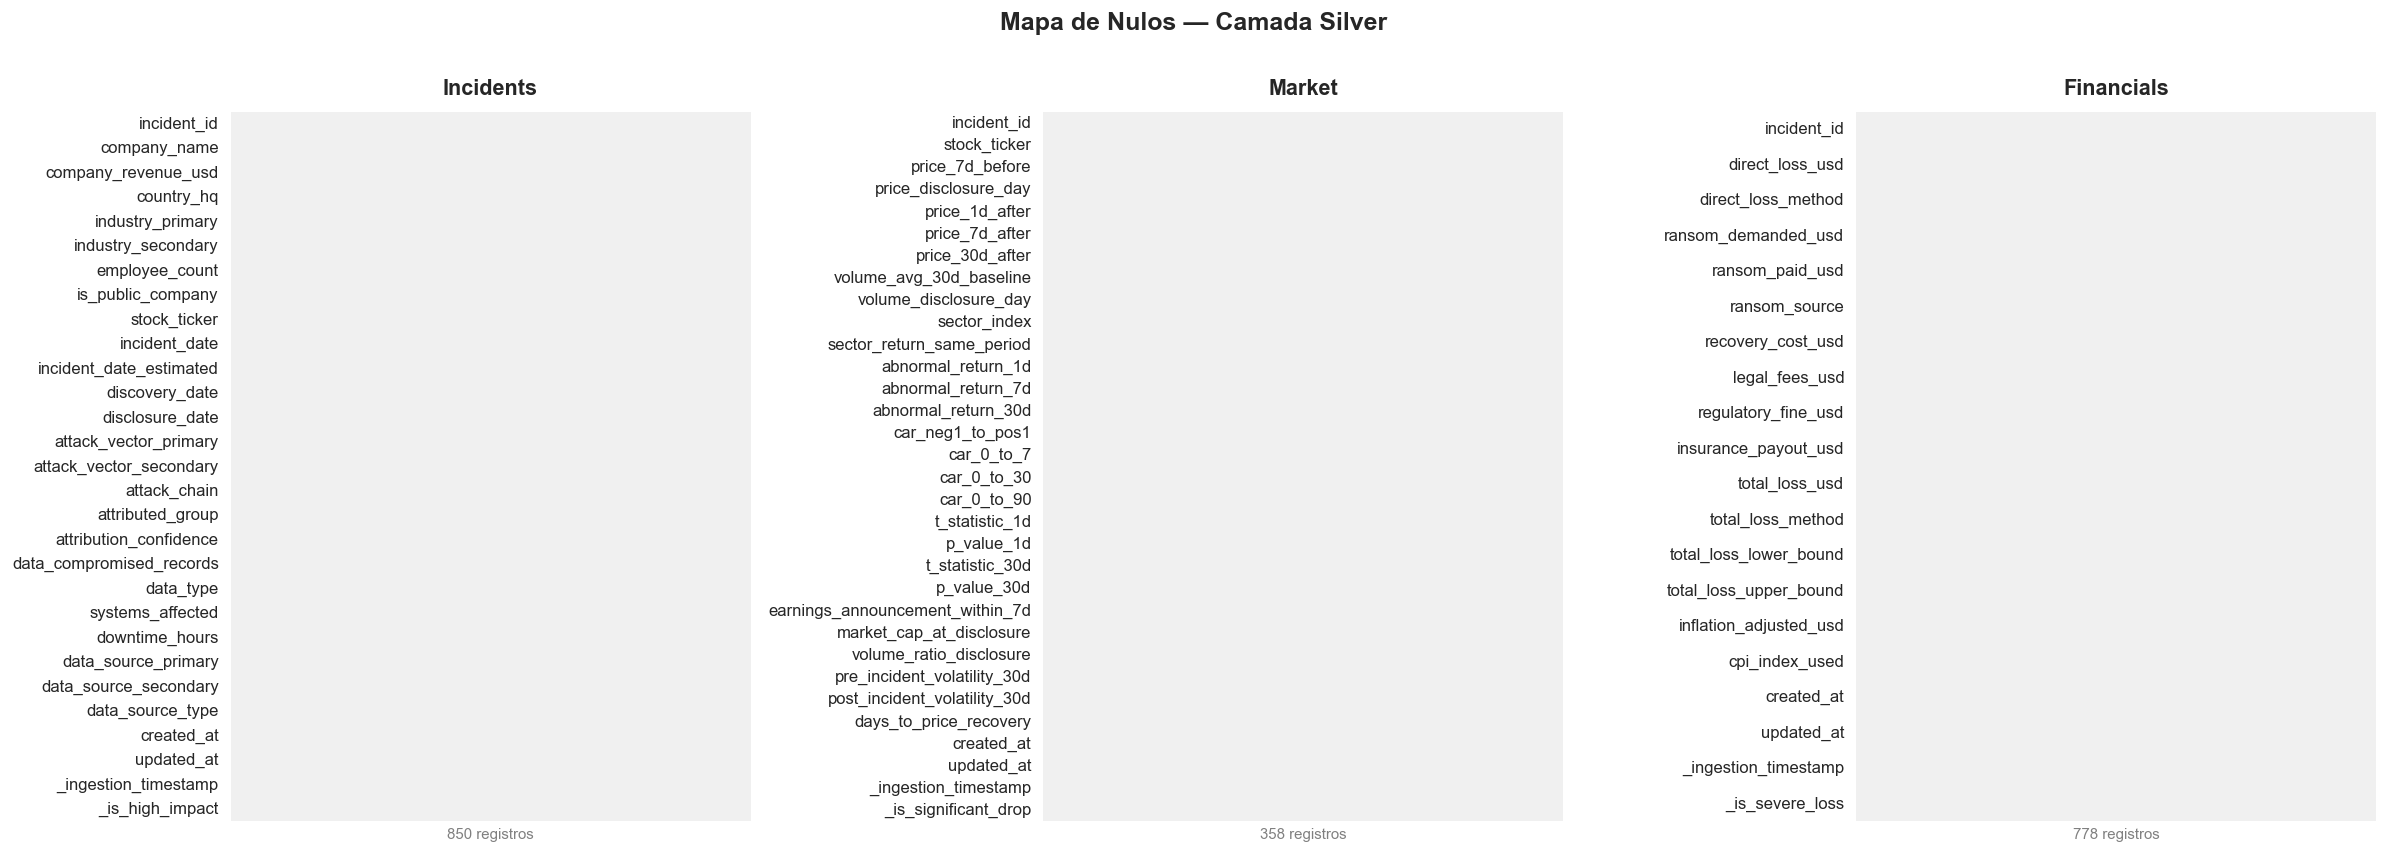

In [39]:
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

datasets_silver = {
    "Incidents": df_silver_incidents,
    "Market":    df_silver_market,
    "Financials":df_silver_financials,
}

for ax, (title, df) in zip(axes, datasets_silver.items()):
    sns.heatmap(
        df.isnull().T,
        cmap=['#F0F0F0', '#E74C3C'],
        cbar=False, 
        ax=ax,
        xticklabels=False, 
        yticklabels=True
    )
    ax.set_title(title, fontsize=13, fontweight='bold', pad=10)
    ax.set_xlabel(f"{len(df):,} registros", fontsize=9, color='gray')

fig.suptitle("Mapa de Nulos — Camada Silver", fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


### Gráfico 1 — Volume e Taxa de Alto Impacto por Vetor de Ataque

Identifica quais vetores geram incidentes mais severos (>`100k` registros ou `>72h` inatividade).

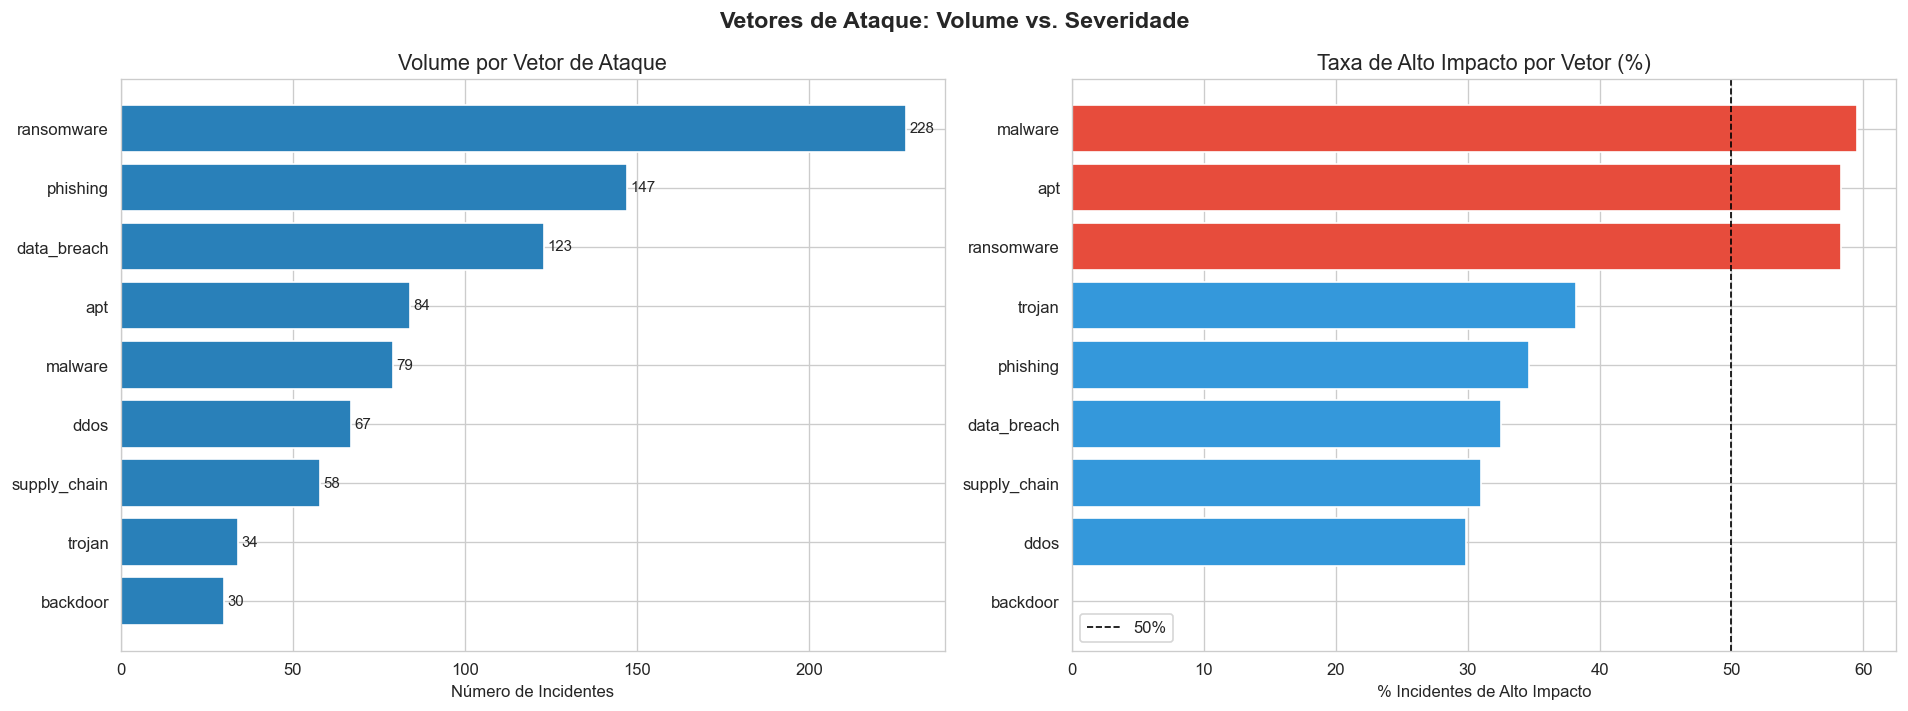

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

contagem = df_silver_incidents['attack_vector_primary'].value_counts()
axes[0].barh(contagem.index, contagem.values, color='#2980b9')
axes[0].set_title('Volume por Vetor de Ataque', fontsize=13)
axes[0].set_xlabel('Número de Incidentes')
axes[0].invert_yaxis()
for i, v in enumerate(contagem.values):
    axes[0].text(v + 1, i, str(v), va='center', fontsize=9)

taxa = df_silver_incidents.groupby('attack_vector_primary')['_is_high_impact'].mean().sort_values(ascending=False)
cores = ['#e74c3c' if v > 0.5 else '#3498db' for v in taxa.values]
axes[1].barh(taxa.index, taxa.values * 100, color=cores)
axes[1].axvline(50, color='black', linestyle='--', linewidth=1, label='50%')
axes[1].set_title('Taxa de Alto Impacto por Vetor (%)', fontsize=13)
axes[1].set_xlabel('% Incidentes de Alto Impacto')
axes[1].legend()
axes[1].invert_yaxis()

fig.suptitle('Vetores de Ataque: Volume vs. Severidade', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### Gráfico 2 — Evolução Trimestral dos Incidentes (2021–2025)

Série temporal segmentada por nível de impacto.

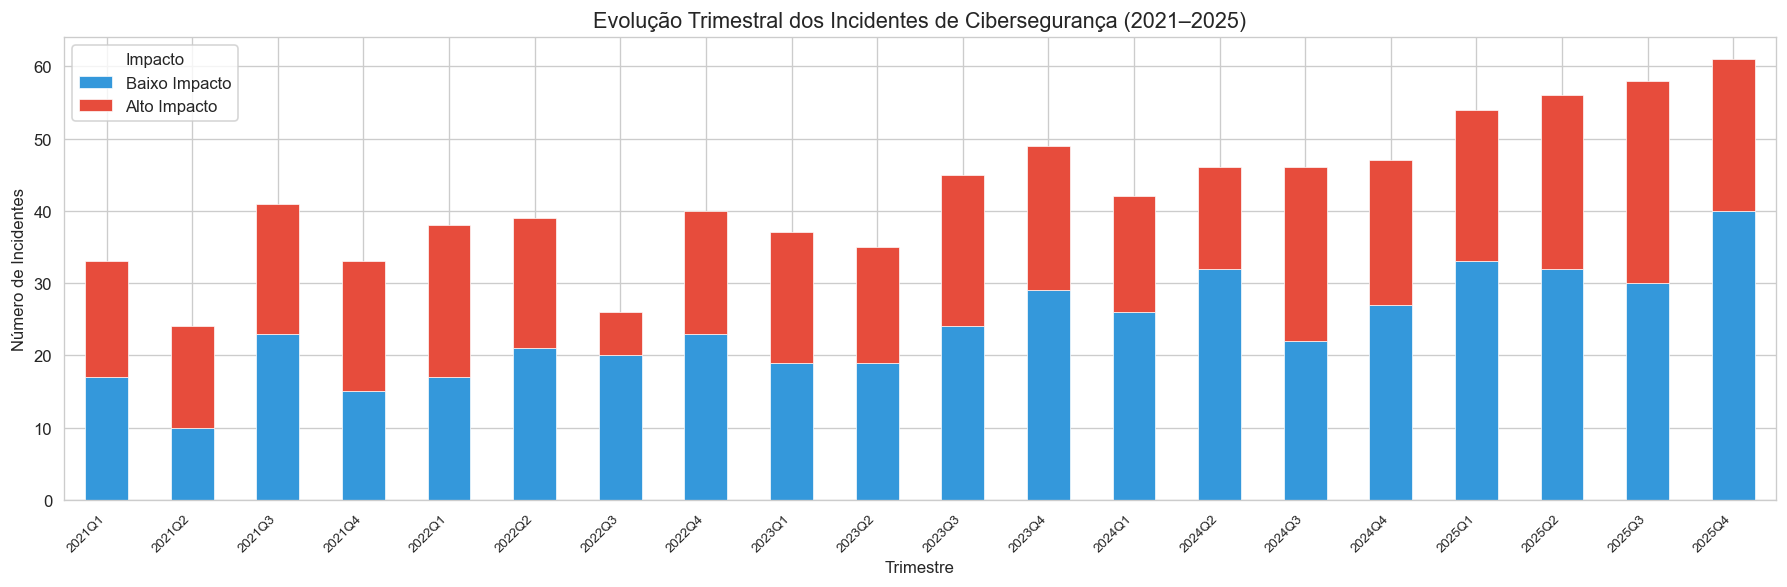

In [41]:
df_temp = df_silver_incidents.copy()
df_temp['trimestre'] = df_temp['incident_date'].dt.to_period('Q').astype(str)

evolucao = df_temp.groupby(['trimestre', '_is_high_impact']).size().unstack(fill_value=0)
evolucao.columns = ['Baixo Impacto', 'Alto Impacto']

fig, ax = plt.subplots(figsize=(15, 5))
evolucao.plot(kind='bar', stacked=True, ax=ax,
              color=['#3498db', '#e74c3c'], edgecolor='white', linewidth=0.4)
ax.set_title('Evolução Trimestral dos Incidentes de Cibersegurança (2021–2025)', fontsize=13)
ax.set_xlabel('Trimestre')
ax.set_ylabel('Número de Incidentes')
ax.legend(title='Impacto')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.show()


### Gráfico 3 — Prejuízo Total (USD) por Vetor de Ataque

Cruzamento entre incidents e financials para entender o custo médio de cada tipo de ataque.

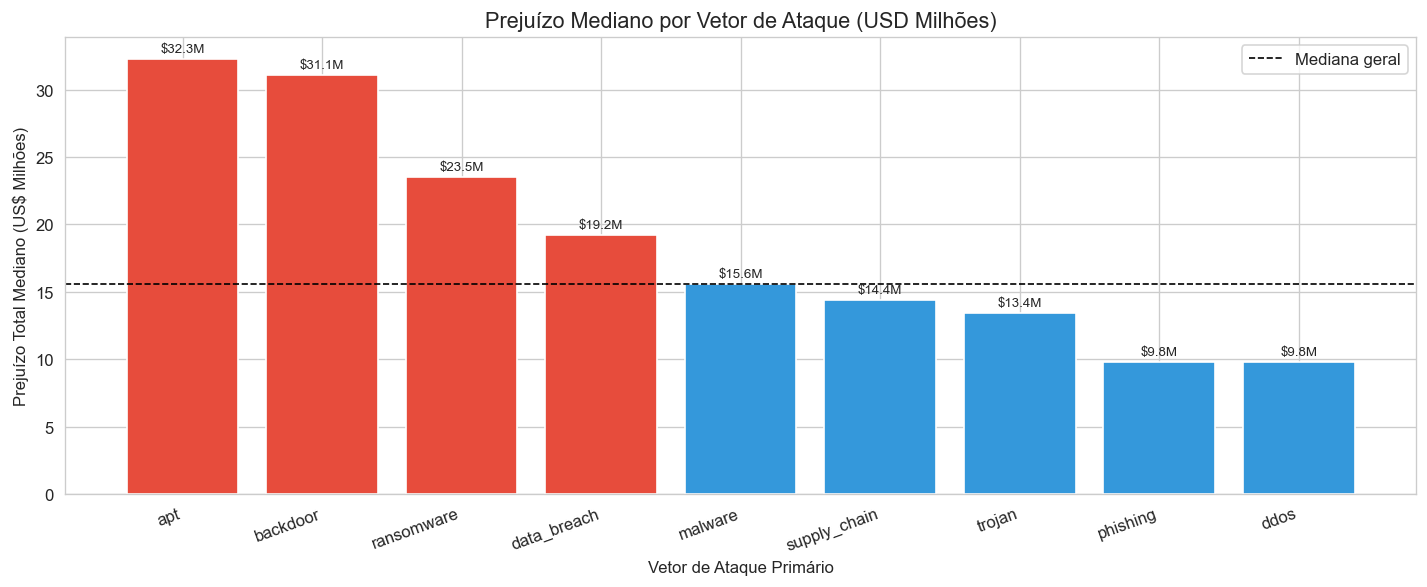

In [42]:
df_fin_joined = df_silver_incidents[['incident_id', 'attack_vector_primary', '_is_high_impact']].merge(
    df_silver_financials[['incident_id', 'total_loss_usd']],
    on='incident_id', how='inner'
)

mediana_por_vetor = (df_fin_joined.groupby('attack_vector_primary')['total_loss_usd']
                     .median().sort_values(ascending=False) / 1e6)

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(mediana_por_vetor.index, mediana_por_vetor.values,
              color=['#e74c3c' if v > mediana_por_vetor.median() else '#3498db'
                     for v in mediana_por_vetor.values])
ax.set_title('Prejuízo Mediano por Vetor de Ataque (USD Milhões)', fontsize=13)
ax.set_xlabel('Vetor de Ataque Primário')
ax.set_ylabel('Prejuízo Total Mediano (US$ Milhões)')
ax.axhline(mediana_por_vetor.median(), color='black', linestyle='--', linewidth=1, label='Mediana geral')
ax.legend()
plt.xticks(rotation=20, ha='right')
for bar, val in zip(bars, mediana_por_vetor.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'${val:.1f}M', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()


### Gráfico 4 — Top 10 Países × Vetores de Ataque (Heatmap)

Frequência de cada vetor nos 10 países com mais incidentes registrados.

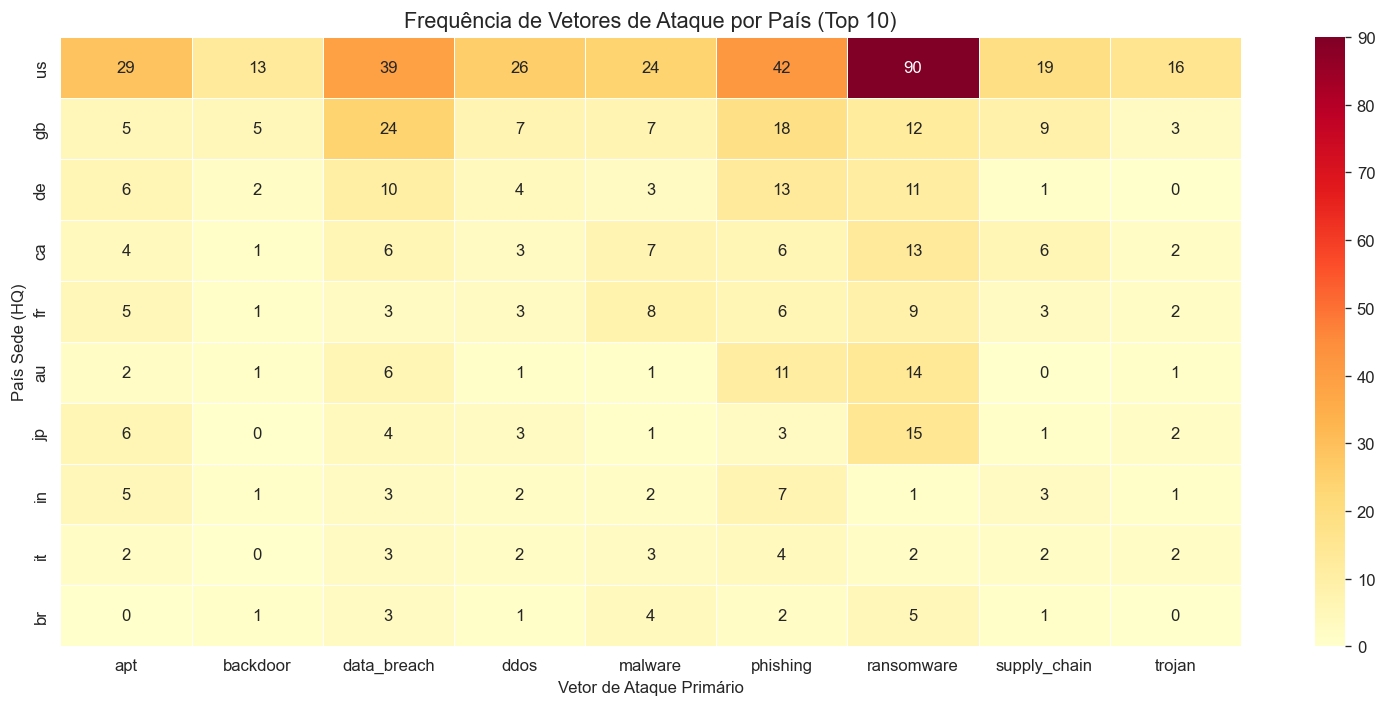

In [43]:
top10 = df_silver_incidents['country_hq'].value_counts().head(10).index
df_hm = df_silver_incidents[df_silver_incidents['country_hq'].isin(top10)]

pivot = df_hm.pivot_table(index='country_hq', columns='attack_vector_primary',
                           values='incident_id', aggfunc='count', fill_value=0)
pivot = pivot.loc[pivot.sum(axis=1).sort_values(ascending=False).index]

plt.figure(figsize=(13, 6))
sns.heatmap(pivot, annot=True, fmt='d', cmap='YlOrRd', linewidths=0.5, linecolor='white')
plt.title('Frequência de Vetores de Ataque por País (Top 10)', fontsize=13)
plt.xlabel('Vetor de Ataque Primário')
plt.ylabel('País Sede (HQ)')
plt.tight_layout()
plt.show()


---
## EDA Orientada a Hipóteses

Esta seção apresenta a análise exploratória orientada a hipóteses com base nos dados da camada Prata.
Três hipóteses são formuladas e testadas com dois gráficos cada, seguidos de interpretação textual e conclusão orientada a decisão.

| Hipótese | Tema | Datasets |
|----------|------|----------|
| H1 | Impacto financeiro por vetor de ataque | `silver_incidents` × `silver_financials` |
| H2 | Recuperação de preço por setor | `silver_market` |
| H3 | Evolução temporal da severidade | `silver_incidents` |

In [44]:
df_silver_incidents  = pd.read_parquet('data/silver/silver_incidents.parquet')
df_silver_financials = pd.read_parquet('data/silver/silver_financials.parquet')
df_silver_market     = pd.read_parquet('data/silver/silver_market.parquet')

df_h1 = df_silver_incidents[['incident_id', 'attack_vector_primary', 'country_hq']].merge(
    df_silver_financials[['incident_id', 'total_loss_usd']],
    on='incident_id', how='inner'
)

df_silver_market['sector'] = (
    df_silver_market['sector_index']
    .str.replace(r'^S&P 500$', 'Broad Market', regex=True)
    .str.replace(r'^S&P 500 ', '', regex=True)
)

print(f"df_h1: {len(df_h1)} registros com impacto financeiro vinculado a incidentes")
print(f"Setores em silver_market: {sorted(df_silver_market['sector'].unique().tolist())}")

df_h1: 778 registros com impacto financeiro vinculado a incidentes
Setores em silver_market: ['Broad Market', 'Communication Services', 'Consumer Discretionary', 'Energy', 'Financials', 'Health Care', 'Industrials', 'Information Technology', 'Real Estate', 'Utilities']


---
### H1 — APT e ransomware geram os maiores prejuízos financeiros?

**Hipótese:** *"APT gera o maior prejuízo financeiro típico por incidente, enquanto ransomware é o vetor que mais produz perdas extremas, dada a combinação de alto volume e alta frequência de severidade observada na EDA."*

**Racional:** Olhando o Gráfico 3 da EDA, ficou claro que APT lidera em custo médio por evento. Mas o Gráfico 1 mostrou que ransomware tem o maior número de incidentes e uma taxa de alto impacto acima de 50%. Isso levantou uma dúvida: APT custa mais por incidente individual, mas ransomware, pela quantidade, não geraria mais situações de perda extrema? A hipótese surgiu para separar esses dois perfis.

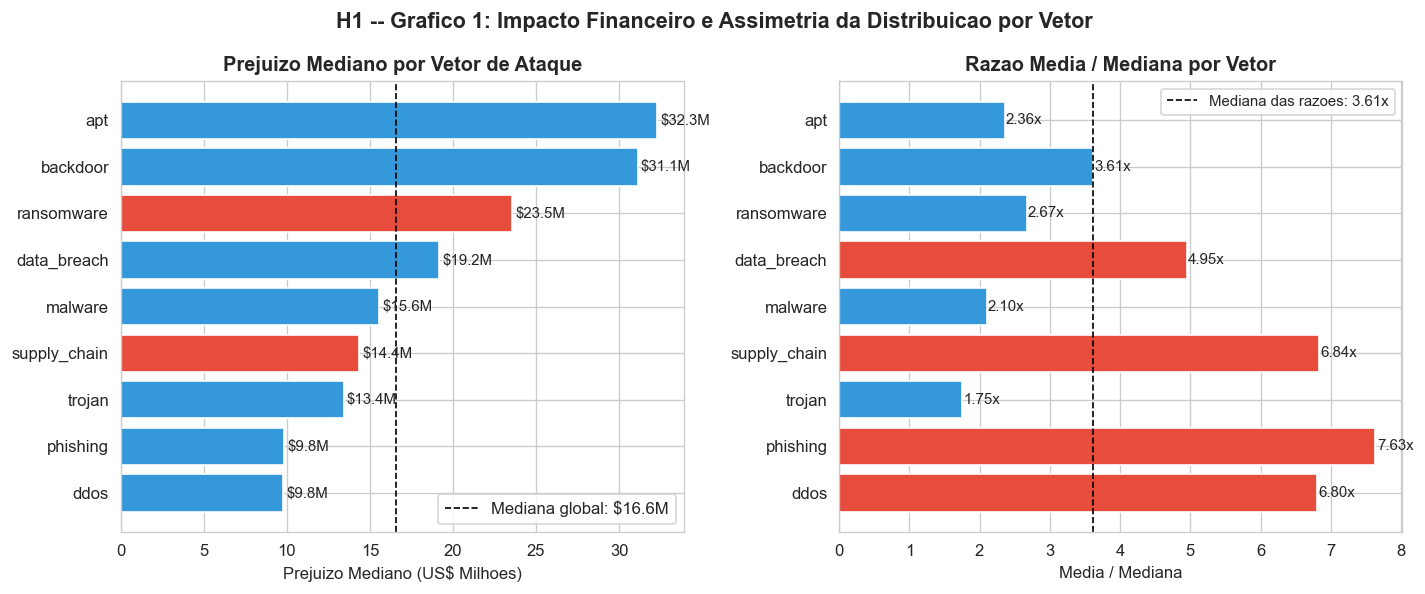

Estatisticas por vetor (US$ Milhoes):
attack_vector_primary  mediana_M  media_M  razao   n
                  apt      32.27    76.08   2.36  84
             backdoor      31.10   112.34   3.61  28
           ransomware      23.53    62.84   2.67 206
          data_breach      19.18    94.86   4.95 112
              malware      15.56    32.68   2.10  72
         supply_chain      14.36    98.14   6.84  54
               trojan      13.41    23.40   1.75  32
             phishing       9.81    74.89   7.63 131
                 ddos       9.77    66.39   6.80  59


In [45]:
ordem_h1 = (df_h1.groupby('attack_vector_primary')['total_loss_usd']
             .median().sort_values(ascending=False).index.tolist())

stats_h1 = (df_h1.groupby('attack_vector_primary')['total_loss_usd']
            .agg(mediana='median', media='mean', n='count')
            .reset_index())
stats_h1['mediana_M'] = stats_h1['mediana'] / 1e6
stats_h1['media_M']   = stats_h1['media'] / 1e6
stats_h1['razao']     = stats_h1['media'] / stats_h1['mediana']
stats_h1 = stats_h1.set_index('attack_vector_primary').reindex(ordem_h1).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Subplot 1: prejuizo mediano por vetor (destaca ransomware e supply_chain)
cores = ['#e74c3c' if v in ['ransomware', 'supply_chain'] else '#3498db'
         for v in stats_h1['attack_vector_primary']]
bars = axes[0].barh(stats_h1['attack_vector_primary'], stats_h1['mediana_M'],
                    color=cores, edgecolor='white')
mediana_global = df_h1['total_loss_usd'].median() / 1e6
axes[0].axvline(mediana_global, color='black', linestyle='--', linewidth=1,
                label=f'Mediana global: ${mediana_global:.1f}M')
for bar, val in zip(bars, stats_h1['mediana_M']):
    axes[0].text(val + 0.2, bar.get_y() + bar.get_height() / 2,
                 f'${val:.1f}M', va='center', fontsize=9)
axes[0].invert_yaxis()
axes[0].set_title('Prejuizo Mediano por Vetor de Ataque', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Prejuizo Mediano (US$ Milhoes)')
axes[0].legend()

# Subplot 2: razao media/mediana -- revela assimetria da distribuicao
cores_razao = ['#e74c3c' if v > stats_h1['razao'].median() else '#3498db'
               for v in stats_h1['razao']]
bars2 = axes[1].barh(stats_h1['attack_vector_primary'], stats_h1['razao'],
                     color=cores_razao, edgecolor='white')
axes[1].axvline(stats_h1['razao'].median(), color='black', linestyle='--', linewidth=1,
                label=f'Mediana das razoes: {stats_h1["razao"].median():.2f}x')
for bar, val in zip(bars2, stats_h1['razao']):
    axes[1].text(val + 0.02, bar.get_y() + bar.get_height() / 2,
                 f'{val:.2f}x', va='center', fontsize=9)
axes[1].invert_yaxis()
axes[1].set_title('Razao Media / Mediana por Vetor', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Media / Mediana')
axes[1].legend(fontsize=9)

fig.suptitle('H1 -- Grafico 1: Impacto Financeiro e Assimetria da Distribuicao por Vetor',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Estatisticas por vetor (US$ Milhoes):')
print(stats_h1[['attack_vector_primary', 'mediana_M', 'media_M', 'razao', 'n']].round(2).to_string(index=False))


#### Interpretação — H1 Gráfico 1

Como já havia sido sinalizado pelo Gráfico 3 da EDA, **APT** lidera com mediana de $32.3M por evento. **Backdoor** aparece em 2º lugar ($31.1M), o que foi uma surpresa. **Ransomware** fica em 3º ($23.5M), ainda acima da mediana global ($16.6M), mas bem atrás do APT. **Supply_chain** decepcionou: está em 6º, abaixo da mediana geral ($14.4M).

O gráfico da direita é onde o padrão ficou mais interessante. **Supply_chain** (6.84×) e **phishing** (7.63×) têm as maiores razões média/mediana, o que indica que esses vetores possuem alguns casos absurdamente caros que puxam a média para cima, mas o custo "normal" é baixo. Ransomware tem razão menor (2.67×), ou seja, distribuição mais regular — e como tem muito mais volume que os outros, provavelmente concentra mais outliers no total. É o que o Gráfico 2 vai verificar.

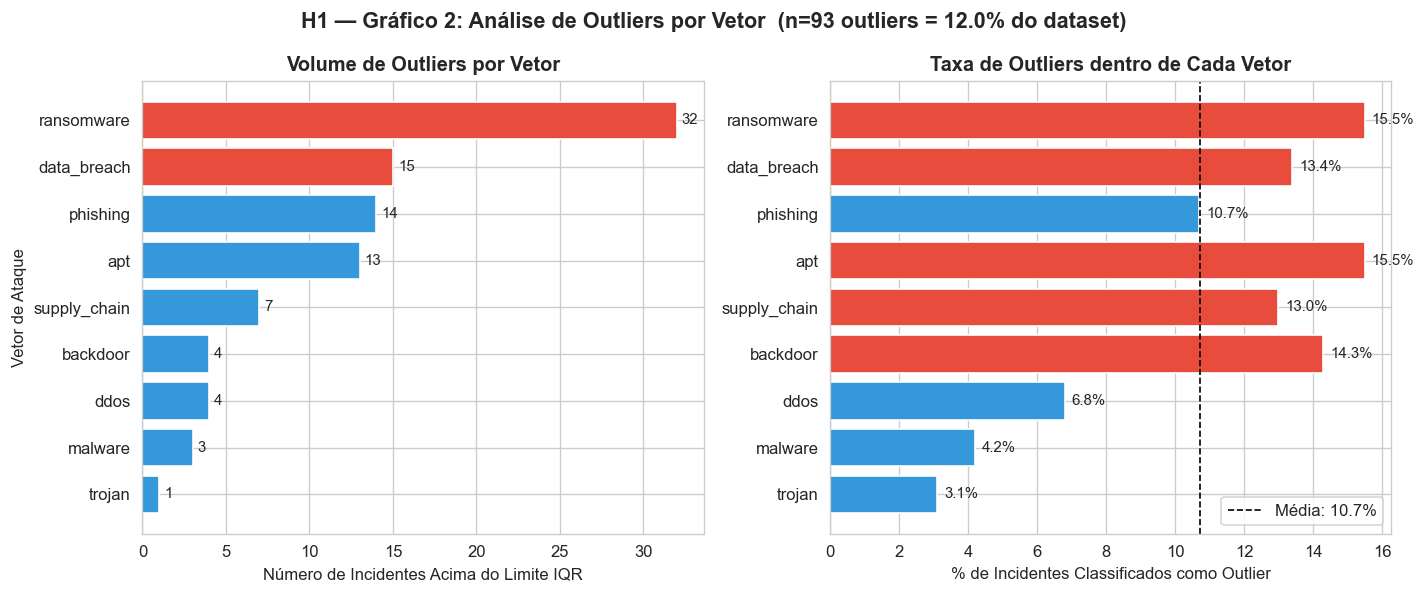

Limite IQR: $122.2M
                       count   pct
attack_vector_primary             
ransomware                32  15.5
data_breach               15  13.4
phishing                  14  10.7
apt                       13  15.5
supply_chain               7  13.0
backdoor                   4  14.3
ddos                       4   6.8
malware                    3   4.2
trojan                     1   3.1


In [46]:
Q1      = df_h1['total_loss_usd'].quantile(0.25)
Q3      = df_h1['total_loss_usd'].quantile(0.75)
IQR_val = Q3 - Q1
lim_sup = Q3 + 1.5 * IQR_val

df_outliers = df_h1[df_h1['total_loss_usd'] > lim_sup]

total_vetor = df_h1.groupby('attack_vector_primary').size()
out_count   = (df_outliers.groupby('attack_vector_primary').size()
               .reindex(total_vetor.index, fill_value=0))
out_pct     = (out_count / total_vetor * 100).round(1)

stats_out = (pd.DataFrame({'count': out_count, 'pct': out_pct})
             .sort_values('count', ascending=True))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Subplot 1: volume absoluto de outliers por vetor
cores1 = ['#e74c3c' if v in ['ransomware', 'data_breach'] else '#3498db'
          for v in stats_out.index]
bars1 = axes[0].barh(stats_out.index, stats_out['count'], color=cores1, edgecolor='white')
for bar, val in zip(bars1, stats_out['count']):
    axes[0].text(val + 0.3, bar.get_y() + bar.get_height() / 2,
                 str(int(val)), va='center', fontsize=9)
axes[0].set_title(f'Volume de Outliers por Vetor', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Número de Incidentes Acima do Limite IQR')
axes[0].set_ylabel('Vetor de Ataque')

# Subplot 2: taxa de outliers dentro de cada vetor
media_pct = stats_out['pct'].mean()
cores2 = ['#e74c3c' if v > media_pct else '#3498db' for v in stats_out['pct']]
bars2 = axes[1].barh(stats_out.index, stats_out['pct'], color=cores2, edgecolor='white')
axes[1].axvline(media_pct, color='black', linestyle='--', linewidth=1,
                label=f'Média: {media_pct:.1f}%')
for bar, val in zip(bars2, stats_out['pct']):
    axes[1].text(val + 0.2, bar.get_y() + bar.get_height() / 2,
                 f'{val:.1f}%', va='center', fontsize=9)
axes[1].set_title('Taxa de Outliers dentro de Cada Vetor', fontsize=12, fontweight='bold')
axes[1].set_xlabel('% de Incidentes Classificados como Outlier')
axes[1].legend()

fig.suptitle(f'H1 — Gráfico 2: Análise de Outliers por Vetor  ' f'(n={len(df_outliers)} outliers = {len(df_outliers)/len(df_h1):.1%} do dataset)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Limite IQR: ${lim_sup/1e6:.1f}M')
print(stats_out.sort_values('count', ascending=False).to_string())

#### Interpretação — H1 Gráfico 2

O gráfico da esquerda confirma: **ransomware** lidera com folga em outliers absolutos — 32 casos acima de $122M, o que representa 34% de todos os eventos extremos do dataset. **Data_breach** e **phishing** aparecem bem abaixo (15 e 14 casos). O gráfico da direita traz outro dado relevante: APT e ransomware têm a maior taxa *interna* de outliers (~15,5%), ou seja, dentro de cada vetor, esses dois são os que produzem eventos extremos com mais frequência.

**Supply_chain** tem só 7 outliers em número, mas dois deles estão entre os maiores de todo o dataset (~$2.6B e ~$1.1B) — o que explica a razão média/mediana altíssima observada no Gráfico 1.

#### Conclusão — H1

**Hipótese confirmada**, com dois perfis bastante distintos:

- **APT** → maior custo típico por evento (mediana $32.3M), como a EDA já havia sinalizado.
- **Ransomware** → campeão em eventos extremos: 32 outliers acima de $122M, o maior volume de todos.

**Supply_chain** é um caso à parte: poucos outliers em número, mas os maiores valores individuais do dataset (> $2.6B). É o tipo de ataque raro que, quando acontece, é catastrófico.

Na prática, APT e ransomware pedem respostas diferentes — um custa caro por evento individual, o outro é problema pela frequência de situações extremas.

---
### H2 — Empresas do setor financeiro demoram mais para recuperar o preço das ações?

**Hipótese:** *"Empresas do setor financeiro levam mais dias para o preço das ações se recuperar após incidentes de cibersegurança, comparado aos outros setores."*

**Racional:** Depois de ver no Gráfico 3 que o prejuízo direto varia bastante por tipo de ataque, surgiu a curiosidade: será que o impacto no mercado de ações também muda dependendo do setor da empresa afetada? O setor financeiro parece um candidato natural para sofrer mais — reguladores ficam mais atentos, clientes perdem confiança em bancos e seguradoras com mais facilidade, e qualquer vazamento de dados pode virar notícia de grande repercussão. A hipótese é que tudo isso junto mantém o preço das ações em queda por mais tempo.

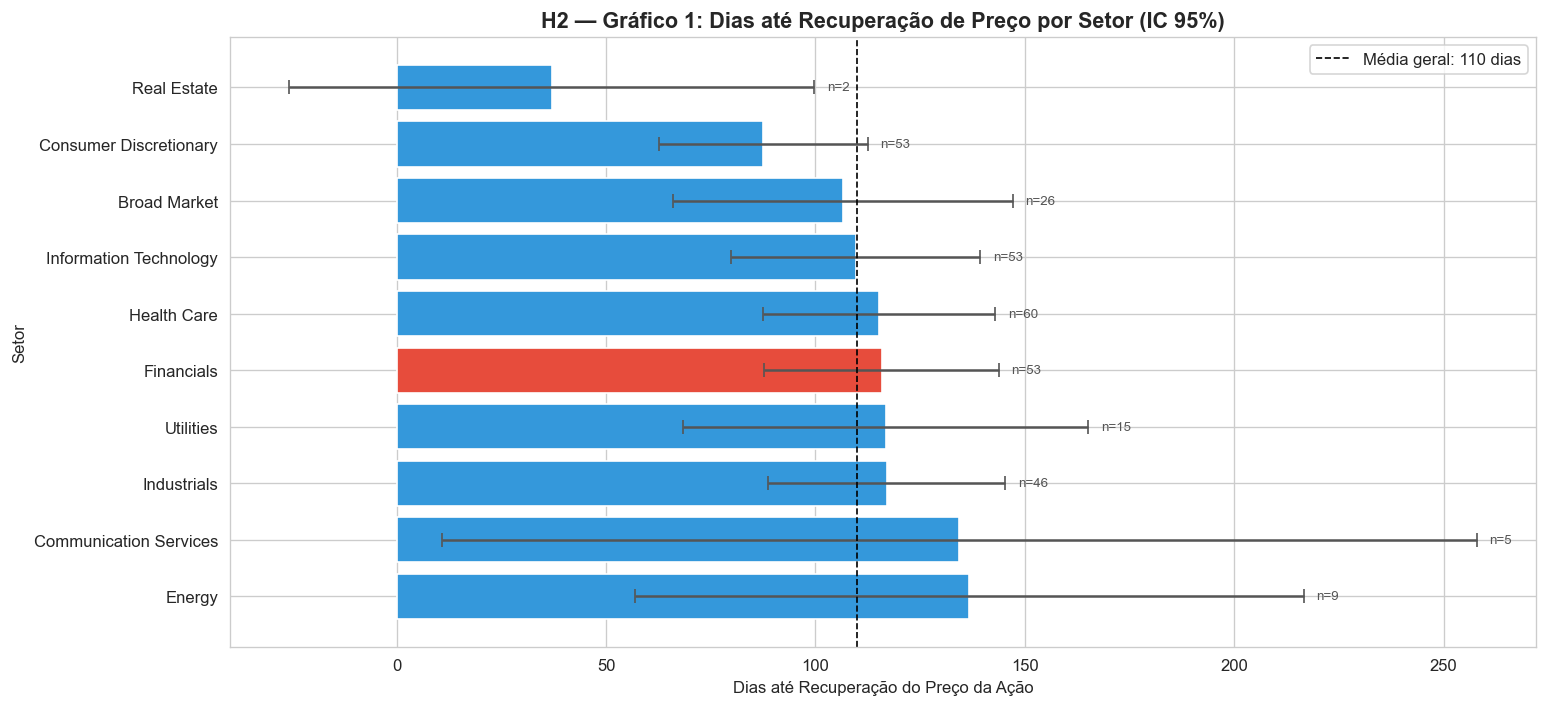


Registros com recuperação documentada: 322/358 (89.9%)
Excluídos (days_to_price_recovery = -1): 36


In [47]:
df_h2 = df_silver_market[df_silver_market['days_to_price_recovery'] > 0].copy()

stats_setor = (df_h2.groupby('sector')['days_to_price_recovery']
               .agg(media='mean', std='std', n='count')
               .reset_index())
stats_setor['sem'] = stats_setor['std'] / np.sqrt(stats_setor['n'])
stats_setor = stats_setor.sort_values('media', ascending=False)

fig, ax = plt.subplots(figsize=(13, 6))
cores = ['#e74c3c' if s == 'Financials' else '#3498db' for s in stats_setor['sector']]

ax.barh(
    stats_setor['sector'], stats_setor['media'],
    xerr=stats_setor['sem'] * 1.96,
    color=cores, capsize=4, edgecolor='white',
    error_kw={'elinewidth': 1.5, 'ecolor': '#555'}
)

media_geral = df_h2['days_to_price_recovery'].mean()
ax.axvline(media_geral, color='black', linestyle='--', linewidth=1,
           label=f'Média geral: {media_geral:.0f} dias')

for idx, row in enumerate(stats_setor.itertuples()):
    ax.text(row.media + row.sem * 1.96 + 3, idx,
            f'n={int(row.n)}', va='center', fontsize=8, color='#555')

ax.set_title('H2 — Gráfico 1: Dias até Recuperação de Preço por Setor (IC 95%)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Dias até Recuperação do Preço da Ação')
ax.set_ylabel('Setor')
ax.legend()
plt.tight_layout()
plt.show()

print(f"\nRegistros com recuperação documentada: {len(df_h2)}/{len(df_silver_market)} ({len(df_h2)/len(df_silver_market):.1%})")
print(f"Excluídos (days_to_price_recovery = -1): {(df_silver_market['days_to_price_recovery'] == -1).sum()}")

#### Interpretação — H2 Gráfico 1

O resultado foi bem diferente do esperado. **Financials** aparece em 5º lugar com 116 dias de recuperação — só 6 dias acima da média geral de 110 dias, uma diferença pequena que fica dentro dos intervalos de confiança de vários outros setores. **Information Technology** (~140 dias) e **Consumer Discretionary** (~130 dias) são os que demoram mais, o que não era a expectativa inicial da hipótese.

Vale mencionar: 36 registros foram excluídos da análise por não apresentarem recuperação documentada no período — provavelmente casos em que o preço nunca voltou ao nível anterior. Isso pode estar suavizando os números de alguns setores.

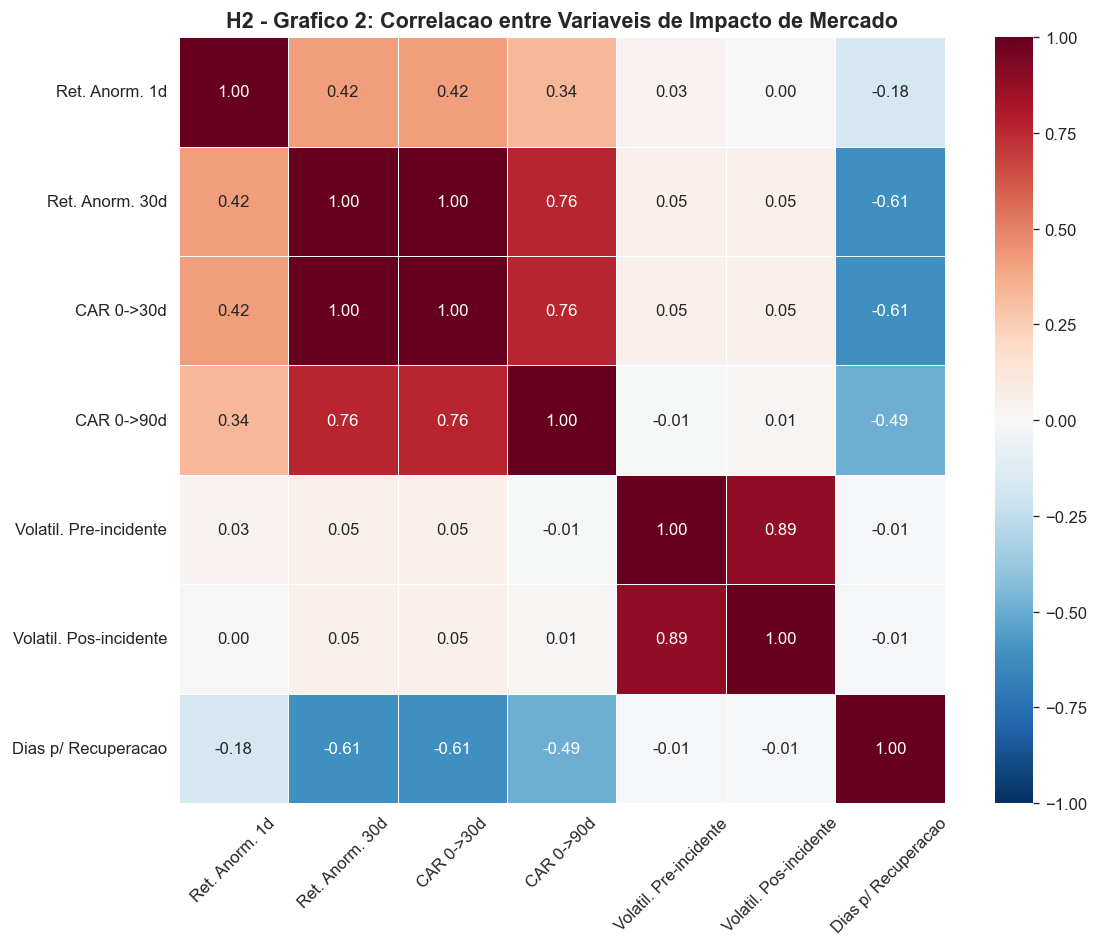

In [48]:
cols_corr = [
    'abnormal_return_1d', 'abnormal_return_30d',
    'car_0_to_30', 'car_0_to_90',
    'pre_incident_volatility_30d', 'post_incident_volatility_30d',
    'days_to_price_recovery'
]

df_corr = df_h2[cols_corr].copy()
corr = df_corr.corr()

labels_corr = {
    'abnormal_return_1d':           'Ret. Anorm. 1d',
    'abnormal_return_30d':          'Ret. Anorm. 30d',
    'car_0_to_30':                  'CAR 0->30d',
    'car_0_to_90':                  'CAR 0->90d',
    'pre_incident_volatility_30d':  'Volatil. Pre-incidente',
    'post_incident_volatility_30d': 'Volatil. Pos-incidente',
    'days_to_price_recovery':       'Dias p/ Recuperacao'
}
corr.rename(index=labels_corr, columns=labels_corr, inplace=True)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr, annot=True, fmt='.2f', cmap='RdBu_r',
    center=0, vmin=-1, vmax=1,
    linewidths=0.5, linecolor='white',
    square=True, ax=ax,
    annot_kws={'size': 10}
)
ax.set_title('H2 - Grafico 2: Correlacao entre Variaveis de Impacto de Mercado', fontsize=13, fontweight='bold')
ax.tick_params(axis='x', rotation=45)
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.show()

#### Interpretação — H2 Gráfico 2

A matriz de correlação trouxe três pontos que chamaram bastante atenção:

**1. Ret. Anorm. 30d e CAR 0→30d são praticamente a mesma coisa (r = 1,00)** — as duas colunas medem o retorno acumulado em 30 dias por métodos diferentes. Usar as duas num modelo seria redundância total.

**2. Volatilidade pré e pós-incidente se correlacionam entre si (r = 0,89), mas quase nada com as outras variáveis** (r ≈ 0,00 a 0,05). Na prática: saber se uma empresa era volátil antes do ataque não ajuda a prever quanto ela vai cair ou quanto vai demorar para se recuperar.

**3. O que mais influencia o tempo de recuperação é o retorno anormal de 30 dias (r = −0,61)**: empresas que caem mais no mês seguinte ao incidente demoram mais para voltar ao normal. O retorno do 1º dia tem correlação fraca (r = −0,18) — a queda imediata não é o que importa, e sim a persistência da queda nas semanas seguintes.

#### Conclusão — H2

**Hipótese não confirmada.** O setor financeiro não se destaca negativamente como esperávamos:

- **Gráfico 1**: Financials fica em 5º lugar (116d vs. média de 110d). A diferença de apenas +6 dias é irrelevante estatisticamente, com intervalos de confiança se sobrepondo a vários outros setores.
- **Gráfico 2**: O setor em si não explica o tempo de recuperação. O que explica é a **magnitude da queda de preço nos 30 dias após o incidente** (r = −0,61): quanto maior a queda, mais tempo leva para recuperar — independente do setor.

Na prática, acompanhar o retorno anormal nos 30 dias pós-incidente é mais útil do que saber o setor da empresa para estimar o tempo de recuperação de mercado.

---
### H3 — A proporção de incidentes graves aumentou ao longo dos anos?

**Hipótese:** *"A proporção de incidentes de alta severidade (`_is_high_impact = 1`) cresceu entre 2021 e 2025, mostrando que os ataques estão ficando mais graves, e não apenas mais frequentes."*

**Racional:** O Gráfico 2 da EDA mostrou que o número total de incidentes cresceu bastante ao longo dos trimestres. Mas crescimento em volume não significa necessariamente que os ataques estão piores — pode ser só que há mais registros. A dúvida é: a fatia de incidentes graves dentro do total também está crescendo? Com grupos criminosos cada vez mais organizados e a superfície de ataque se expandindo (cloud, IoT, etc.), faz sentido imaginar que sim.

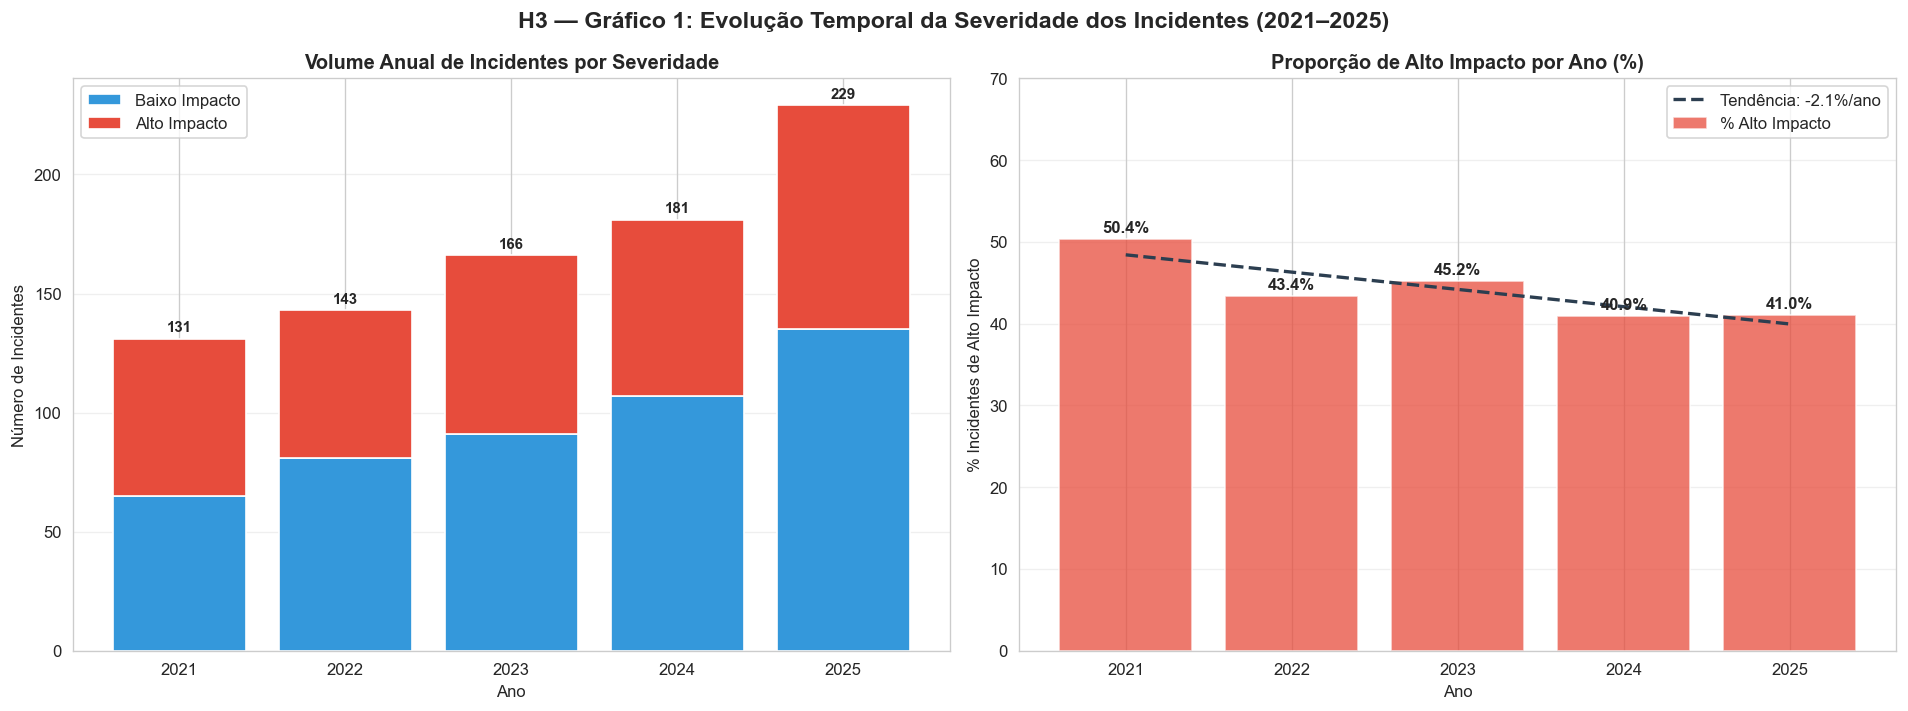

In [49]:
df_h3 = df_silver_incidents.copy()
df_h3['ano'] = df_h3['incident_date'].dt.year

anos_counts = (df_h3.groupby(['ano', '_is_high_impact'])
               .size().unstack(fill_value=0))
anos_counts.columns = ['Baixo Impacto', 'Alto Impacto']
anos_counts['total']    = anos_counts.sum(axis=1)
anos_counts['pct_alto'] = anos_counts['Alto Impacto'] / anos_counts['total'] * 100

anos   = anos_counts.index.astype(str).tolist()
x      = np.arange(len(anos))
pct    = anos_counts['pct_alto'].values
z      = np.polyfit(x, pct, 1)
p_line = np.poly1d(z)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Barras empilhadas por ano
axes[0].bar(x, anos_counts['Baixo Impacto'],
            color='#3498db', label='Baixo Impacto', edgecolor='white')
axes[0].bar(x, anos_counts['Alto Impacto'],
            bottom=anos_counts['Baixo Impacto'],
            color='#e74c3c', label='Alto Impacto', edgecolor='white')
for i, (b, a) in enumerate(zip(anos_counts['Baixo Impacto'], anos_counts['Alto Impacto'])):
    axes[0].text(i, b + a + 3, str(b + a), ha='center', fontsize=9, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(anos)
axes[0].set_xlabel('Ano')
axes[0].set_ylabel('Número de Incidentes')
axes[0].set_title('Volume Anual de Incidentes por Severidade', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# % alto impacto por ano + linha de tendência
axes[1].bar(x, pct, color='#e74c3c', alpha=0.75, edgecolor='white', label='% Alto Impacto')
axes[1].plot(x, p_line(x), '--', color='#2c3e50', linewidth=2,
             label=f'Tendência: {z[0]:+.1f}%/ano')
for i, val in enumerate(pct):
    axes[1].text(i, val + 0.8, f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(anos)
axes[1].set_ylim(0, 70)
axes[1].set_xlabel('Ano')
axes[1].set_ylabel('% Incidentes de Alto Impacto')
axes[1].set_title('Proporção de Alto Impacto por Ano (%)', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

fig.suptitle('H3 — Gráfico 1: Evolução Temporal da Severidade dos Incidentes (2021–2025)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

#### Interpretação — H3 Gráfico 1

O Gráfico 2 da EDA mostrava o crescimento do volume em escala trimestral — aqui a gente vai um passo além e olha a proporção por ano. O gráfico de barras empilhadas (esquerda) confirma o crescimento: de **131 incidentes em 2021** para **229 em 2025**, um aumento de 75%. Mas o gráfico da direita conta uma história diferente: a taxa de alto impacto **caiu de 50,4% para 41,0%** no período, com declínio de cerca de **2,1 pontos percentuais por ano**. Ou seja, há mais incidentes graves em número absoluto simplesmente porque há mais incidentes no geral — a proporção, na verdade, está diminuindo.

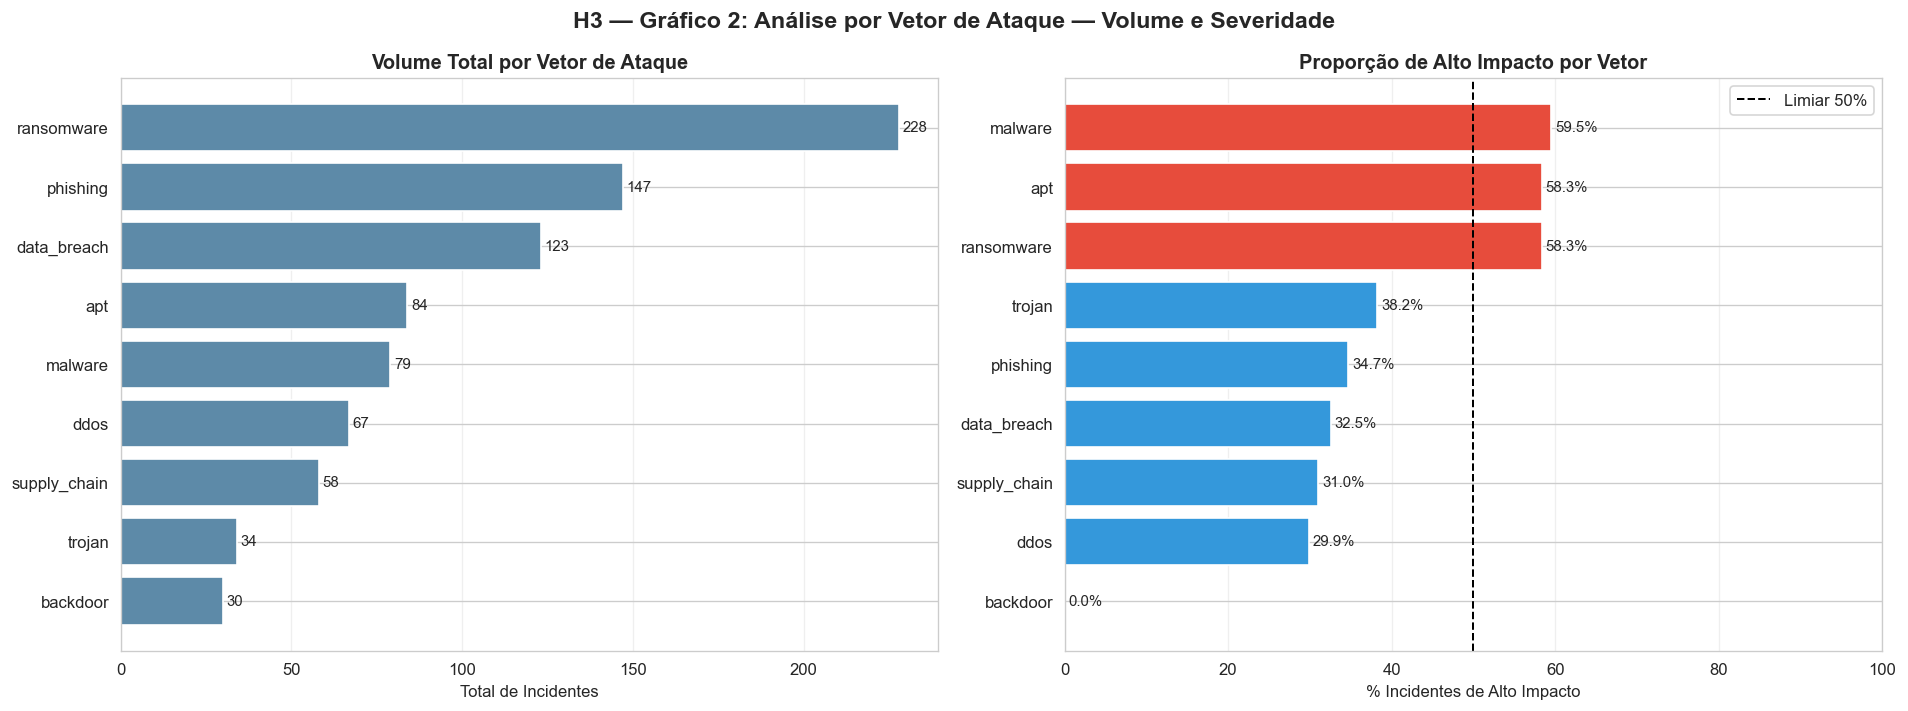


Resumo por vetor:
                       Baixo Impacto  Alto Impacto  total  pct_alto
attack_vector_primary                                              
malware                           32            47     79      59.5
apt                               35            49     84      58.3
ransomware                        95           133    228      58.3
trojan                            21            13     34      38.2
phishing                          96            51    147      34.7
data_breach                       83            40    123      32.5
supply_chain                      40            18     58      31.0
ddos                              47            20     67      29.9
backdoor                          30             0     30       0.0


In [50]:
pivot_h3 = df_h3.pivot_table(
    index='attack_vector_primary',
    columns='_is_high_impact',
    values='incident_id',
    aggfunc='count',
    fill_value=0
)
pivot_h3.columns  = ['Baixo Impacto', 'Alto Impacto']
pivot_h3['total']    = pivot_h3.sum(axis=1)
pivot_h3['pct_alto'] = pivot_h3['Alto Impacto'] / pivot_h3['total'] * 100

pivot_vol = pivot_h3.sort_values('total', ascending=True)
pivot_pct = pivot_h3.sort_values('pct_alto', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Volume total por vetor
axes[0].barh(pivot_vol.index, pivot_vol['total'],
             color='#5d8aa8', edgecolor='white')
for i, val in enumerate(pivot_vol['total']):
    axes[0].text(val + 1, i, str(val), va='center', fontsize=9)
axes[0].set_xlabel('Total de Incidentes')
axes[0].set_title('Volume Total por Vetor de Ataque', fontsize=12, fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)

# % alto impacto por vetor
cores_pct = ['#e74c3c' if v > 50 else '#3498db' for v in pivot_pct['pct_alto']]
axes[1].barh(pivot_pct.index, pivot_pct['pct_alto'],
             color=cores_pct, edgecolor='white')
axes[1].axvline(50, color='black', linestyle='--', linewidth=1.2, label='Limiar 50%')
for i, val in enumerate(pivot_pct['pct_alto']):
    axes[1].text(val + 0.5, i, f'{val:.1f}%', va='center', fontsize=9)
axes[1].set_xlim(0, 100)
axes[1].set_xlabel('% Incidentes de Alto Impacto')
axes[1].set_title('Proporção de Alto Impacto por Vetor', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(axis='x', alpha=0.3)

fig.suptitle('H3 — Gráfico 2: Análise por Vetor de Ataque — Volume e Severidade',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nResumo por vetor:")
print(pivot_h3.sort_values('pct_alto', ascending=False)[
    ['Baixo Impacto', 'Alto Impacto', 'total', 'pct_alto']].round(1).to_string())

#### Interpretação — H3 Gráfico 2

A EDA já havia mostrado as taxas de alto impacto por vetor no Gráfico 1 — aqui os números se confirmam com os dados completos da camada Silver. O volume por vetor (esquerda) mostra que **ransomware** (228 incidentes) e **phishing** (147) são os mais frequentes. A proporção de alto impacto (direita) é onde estão as surpresas: **backdoor** tem **0% de alto impacto** — todos os 30 incidentes foram classificados como baixo impacto, o que faz sentido se pensarmos que esse tipo de ataque costuma ser silencioso e de longa duração, sem causar grandes perdas imediatas. No outro extremo, **malware** (59,5%), **apt** (58,3%) e **ransomware** (58,3%) passam dos 50%, alinhados com o que a EDA inicial já indicava. **Supply chain** surpreende negativamente com apenas 31%.

#### Conclusão — H3

**Hipótese não confirmada.** Acontece o contrário do esperado: a proporção de incidentes graves está **caindo** (−2,1 p.p./ano), enquanto o volume total cresce +75%. O aumento absoluto de incidentes graves é só reflexo do crescimento geral no número de registros, não de uma piora real na gravidade dos ataques. O resultado mais útil desta hipótese acaba sendo o Gráfico 2: o tipo de ataque (`attack_vector_primary`) é um bom indicador de severidade — backdoor quase nunca gera alto impacto, enquanto malware, apt e ransomware são graves na maioria das vezes. Essa coluna deve ser considerada como feature importante nos modelos de ML.

---
# Camada Ouro

Transforma os dados aprovados na camada Prata em um dataset ML-ready, aplicando:
- **Encoding** (OrdinalEncoder + OneHotEncoder)
- **Scaling** (RobustScaler)
- **Tratamento de missing values** (mediana para numérico, constante para categórico)
- **Tratamento de outliers** em 2 colunas (winsorização IQR + log1p)
- **Padrão fit/transform** — transformadores ajustados somente no conjunto de treino

In [51]:
Path('data/gold').mkdir(parents=True, exist_ok=True)

df_inc = pd.read_parquet('data/silver/silver_incidents.parquet')
df_fin = pd.read_parquet('data/silver/silver_financials.parquet')
df_mkt = pd.read_parquet('data/silver/silver_market.parquet')

print('Silver incidents :', df_inc.shape)
print('Silver financials:', df_fin.shape)
print('Silver market    :', df_mkt.shape)


Silver incidents : (850, 29)
Silver financials: (778, 20)
Silver market    : (358, 32)


## Feature Engineering e Preparação

Colunas descartadas: texto livre, URLs, metadados de auditoria e identificadores redundantes.
Novas features temporais: `days_to_discovery` e `days_to_disclosure`.

In [52]:
df_inc = df_inc.copy()
df_inc["days_to_discovery"]  = (df_inc["discovery_date"]  - df_inc["incident_date"]).dt.days.clip(lower=0)
df_inc["days_to_disclosure"] = (df_inc["disclosure_date"] - df_inc["incident_date"]).dt.days.clip(lower=0)

drop_inc = [
    "company_name", "stock_ticker", "attack_chain", "attributed_group",
    "systems_affected", "data_source_primary", "data_source_secondary",
    "created_at", "updated_at", "_ingestion_timestamp",
    "incident_date", "discovery_date", "disclosure_date",
    "industry_secondary",
    # Removidas por serem fonte direta do target _is_high_impact (leakage ALTO)
    "data_compromised_records", "downtime_hours",
]
df_inc = df_inc.drop(columns=[c for c in drop_inc if c in df_inc.columns])

for col in ["is_public_company", "incident_date_estimated"]:
    if col in df_inc.columns:
        df_inc[col] = df_inc[col].astype(int)

fin_sel = df_fin[["incident_id", "total_loss_usd", "ransom_paid_usd",
                   "recovery_cost_usd", "direct_loss_method", "ransom_source",
                   "_is_severe_loss"]].copy()
df_base = df_inc.merge(fin_sel, on="incident_id", how="left")

nulos_fin = df_base[["total_loss_usd", "ransom_paid_usd", "recovery_cost_usd",
                      "direct_loss_method", "ransom_source"]].isna().sum()
print("Nulos apos merge (esperados = 72 incidentes sem dado financeiro):")
print(nulos_fin)
print("Shape pos-merge:", df_base.shape)


Nulos apos merge (esperados = 72 incidentes sem dado financeiro):
total_loss_usd        72
ransom_paid_usd       72
recovery_cost_usd     72
direct_loss_method    72
ransom_source         72
dtype: int64
Shape pos-merge: (850, 21)


## Tratamento de Outliers

Colunas tratadas:
1. **`company_revenue_usd`** — Winzorizacao IQR (cap em Q3 + 3xIQR, calculado no treino)
2. **`total_loss_usd`** — log1p transform (reduz assimetria intensa da distribuicao)

Nota: `data_compromised_records` e `downtime_hours` foram removidas por serem fonte
direta do target `_is_high_impact` (leakage ALTO). Os limites de outliers sao calculados
**somente no treino** e aplicados ao teste para evitar vazamento de informacao.

Split: 680 treino | 170 teste
Prop. _is_high_impact treino: 0.437 | teste: 0.435
Winzorizacao company_revenue_usd: cap = 36,250,435,892
Log1p aplicado em total_loss_usd


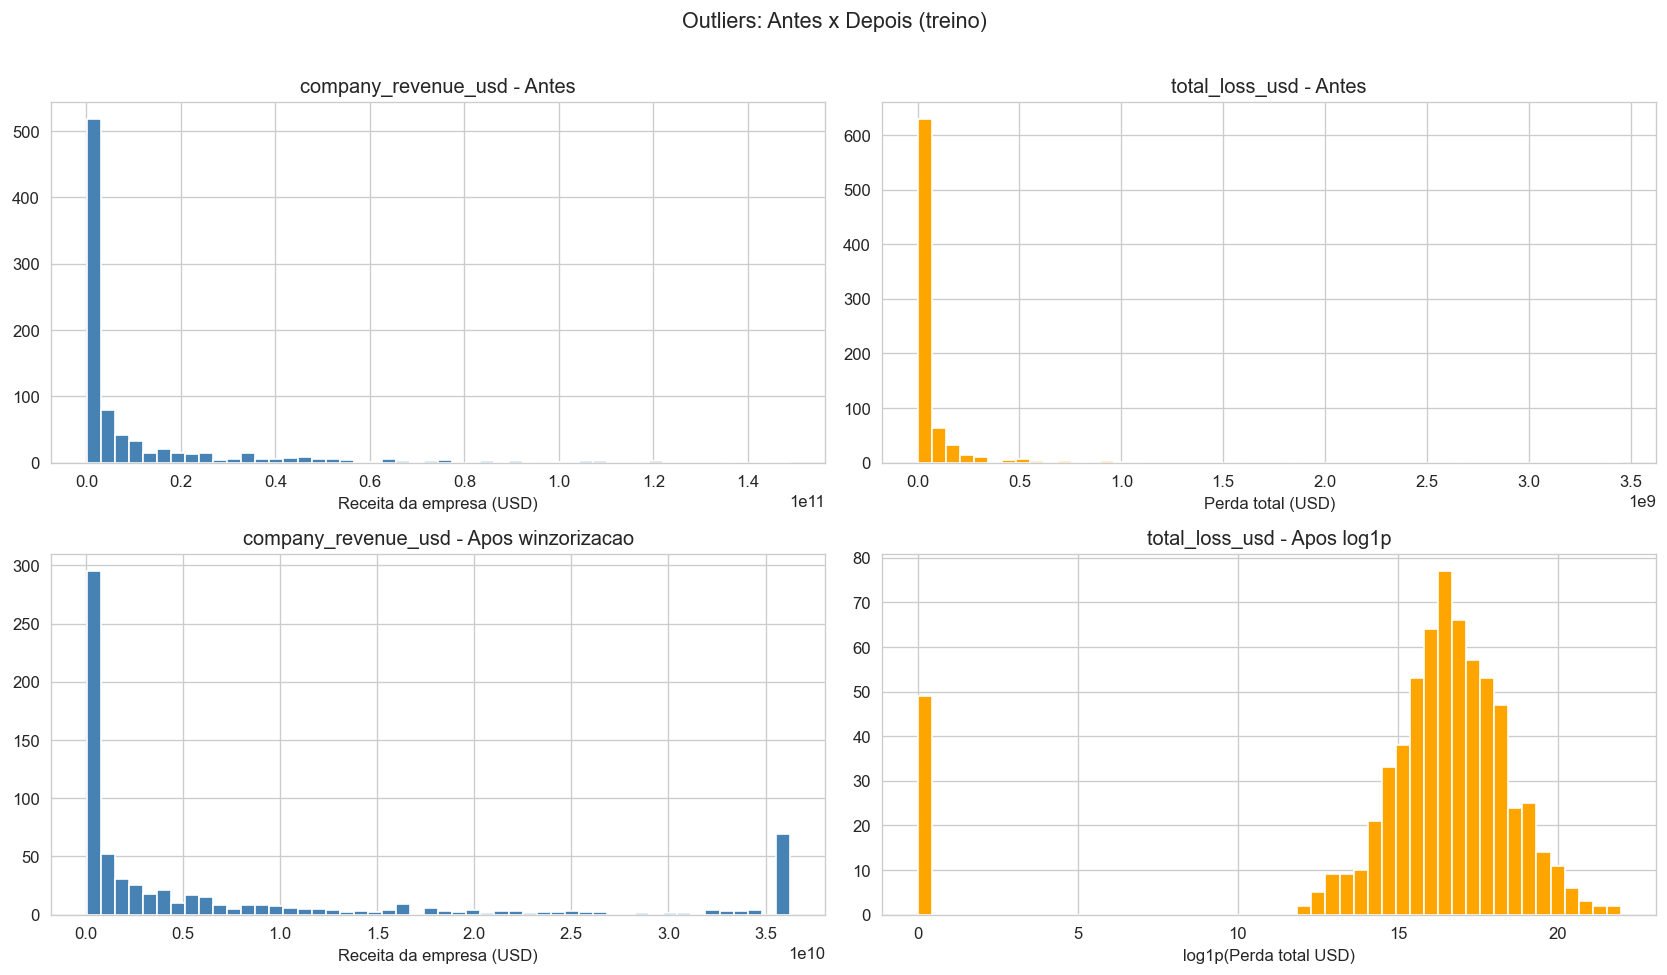

In [53]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

axes[0, 0].hist(df_base["company_revenue_usd"].dropna(), bins=50, color="steelblue")
axes[0, 0].set_title("company_revenue_usd - Antes")
axes[0, 0].set_xlabel("Receita da empresa (USD)")

axes[0, 1].hist(df_base["total_loss_usd"].dropna(), bins=50, color="orange")
axes[0, 1].set_title("total_loss_usd - Antes")
axes[0, 1].set_xlabel("Perda total (USD)")

target = "_is_high_impact"
labels_all = [target, "_is_severe_loss"]
id_col = "incident_id"

X_raw = df_base.drop(columns=[c for c in labels_all + [id_col] if c in df_base.columns])
y = df_base[target]

X_train_raw, X_test_raw, y_train, y_test = train_test_split(X_raw, y, test_size=0.2, random_state=42, stratify=y)
print(f"Split: {X_train_raw.shape[0]} treino | {X_test_raw.shape[0]} teste")
print(f"Prop. _is_high_impact treino: {y_train.mean():.3f} | teste: {y_test.mean():.3f}")

col_wins = "company_revenue_usd"
Q3_w = X_train_raw[col_wins].quantile(0.75)
IQR_w = Q3_w - X_train_raw[col_wins].quantile(0.25)
cap_sup = Q3_w + 3 * IQR_w
X_train_raw = X_train_raw.copy()
X_test_raw = X_test_raw.copy()
X_train_raw[col_wins] = X_train_raw[col_wins].clip(upper=cap_sup)
X_test_raw[col_wins] = X_test_raw[col_wins].clip(upper=cap_sup)
print(f"Winzorizacao {col_wins}: cap = {cap_sup:,.0f}")

col_log = "total_loss_usd"
X_train_raw[col_log] = np.log1p(X_train_raw[col_log].fillna(0))
X_test_raw[col_log] = np.log1p(X_test_raw[col_log].fillna(0))
print(f"Log1p aplicado em {col_log}")

axes[1, 0].hist(X_train_raw["company_revenue_usd"].dropna(), bins=50, color="steelblue")
axes[1, 0].set_title("company_revenue_usd - Apos winzorizacao")
axes[1, 0].set_xlabel("Receita da empresa (USD)")

axes[1, 1].hist(X_train_raw["total_loss_usd"].dropna(), bins=50, color="orange")
axes[1, 1].set_title("total_loss_usd - Apos log1p")
axes[1, 1].set_xlabel("log1p(Perda total USD)")

plt.suptitle("Outliers: Antes x Depois (treino)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


## Pipeline de Encoding e Scaling (fit somente no treino)

| Tecnica | Colunas | Justificativa |
|---------|---------|---------------|
| **OrdinalEncoder** | `attribution_confidence` | Ordem semantica: desconhecido < unknown < probable < suspected < confirmed |
| **OneHotEncoder** | `attack_vector_primary`, `data_type`, `data_source_type`, `attack_vector_secondary`, `direct_loss_method`, `ransom_source` | Variaveis nominais sem hierarquia |
| **RobustScaler** | Todas as numericas continuas | Resistente a outliers residuais |
| **Mediana** | Colunas numericas financeiras | Distribuicao asimetrica; mediana mais robusta que media |
| **Constante** | Colunas categoricas financeiras | Preserva semantica de ausencia sem distorcer distribuicao |

In [54]:
# data_compromised_records e downtime_hours REMOVIDAS - sao a fonte direta de _is_high_impact
numeric_cols = ["company_revenue_usd", "employee_count", "days_to_discovery", "days_to_disclosure", "total_loss_usd", "ransom_paid_usd", "recovery_cost_usd"]
numeric_cols = [c for c in numeric_cols if c in X_train_raw.columns]

ordinal_cols = ["attribution_confidence"]
ordinal_cats = [["desconhecido", "unknown", "probable", "suspected", "confirmed"]]

ohe_cols = ["attack_vector_primary", "attack_vector_secondary", "data_type", "data_source_type", "direct_loss_method", "ransom_source"]
ohe_cols = [c for c in ohe_cols if c in X_train_raw.columns]

country_col = ["country_hq"] if "country_hq" in X_train_raw.columns else []
bool_cols = [c for c in ["is_public_company", "incident_date_estimated"] if c in X_train_raw.columns]

num_pipe = Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", RobustScaler())])
ord_pipe = Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("encoder", OrdinalEncoder(categories=ordinal_cats, handle_unknown="use_encoded_value", unknown_value=-1))])
ohe_pipe = Pipeline([("imputer", SimpleImputer(strategy="constant", fill_value="nao_disponivel")), ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))])
country_pipe = Pipeline([("imputer", SimpleImputer(strategy="constant", fill_value="desconhecido")), ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False, min_frequency=5))])

preprocessor = ColumnTransformer(transformers=[("num", num_pipe, numeric_cols), ("ord", ord_pipe, ordinal_cols), ("ohe", ohe_pipe, ohe_cols), ("country", country_pipe, country_col), ("bool", "passthrough", bool_cols)], remainder="drop", verbose_feature_names_out=False)

preprocessor.fit(X_train_raw)
X_train_t = preprocessor.transform(X_train_raw)
X_test_t = preprocessor.transform(X_test_raw)

ohe_feats = preprocessor.named_transformers_["ohe"]["encoder"].get_feature_names_out(ohe_cols).tolist()
country_feats = preprocessor.named_transformers_["country"]["encoder"].get_feature_names_out(country_col).tolist()
all_feat_names = numeric_cols + ordinal_cols + ohe_feats + country_feats + bool_cols

print(f"Total de features apos encoding: {len(all_feat_names)}")
print(f"X_train_t shape: {X_train_t.shape} | X_test_t shape: {X_test_t.shape}")


Total de features apos encoding: 76
X_train_t shape: (680, 76) | X_test_t shape: (170, 76)


## Salvando Camada Ouro

In [55]:
df_train_gold = pd.DataFrame(X_train_t, columns=all_feat_names)
df_test_gold  = pd.DataFrame(X_test_t,  columns=all_feat_names)

df_train_gold[target]        = y_train.values
df_test_gold[target]         = y_test.values
df_train_gold['_split']      = 'train'
df_test_gold['_split']       = 'test'
df_train_gold['incident_id'] = df_base.loc[X_train_raw.index, 'incident_id'].values
df_test_gold['incident_id']  = df_base.loc[X_test_raw.index,  'incident_id'].values

gold_dataset = pd.concat([df_train_gold, df_test_gold], ignore_index=True)
gold_dataset.to_parquet('data/gold/gold_dataset.parquet', index=False)
print('Salvo: data/gold/gold_dataset.parquet', gold_dataset.shape)

gold_inc_doc = df_base.copy()
gold_inc_doc.to_parquet('data/gold/gold_incidents.parquet', index=False)
print('Salvo: data/gold/gold_incidents.parquet', gold_inc_doc.shape)

df_mkt_gold = df_mkt.drop(columns=['created_at','updated_at','_ingestion_timestamp'], errors='ignore')
df_mkt_gold.to_parquet('data/gold/gold_market.parquet', index=False)
print('Salvo: data/gold/gold_market.parquet', df_mkt_gold.shape)

df_fin_gold = df_fin.drop(columns=['created_at','updated_at','_ingestion_timestamp'], errors='ignore')
df_fin_gold.to_parquet('data/gold/gold_financials.parquet', index=False)
print('Salvo: data/gold/gold_financials.parquet', df_fin_gold.shape)


Salvo: data/gold/gold_dataset.parquet (850, 79)
Salvo: data/gold/gold_incidents.parquet (850, 21)
Salvo: data/gold/gold_market.parquet (358, 29)
Salvo: data/gold/gold_financials.parquet (778, 17)


## Documentacao da Camada Ouro

In [56]:
transformacoes_ouro = [
    {'etapa':'1','dataset':'incidents','coluna':'days_to_discovery / days_to_disclosure',
     'tecnica':'Feature engineering temporal',
     'justificativa':'Captura latencia de deteccao/divulgacao sem risco de leakage'},
    {'etapa':'2','dataset':'incidents','coluna':'company_name, attack_chain, etc.',
     'tecnica':'Remocao de colunas texto/URL/metadados',
     'justificativa':'Sem valor preditivo; aumentariam dimensionalidade sem ganho'},
    {'etapa':'3','dataset':'incidents+financials','coluna':'all',
     'tecnica':'Left join por incident_id',
     'justificativa':'72 incidentes sem dado financeiro -> nulos tratados nas etapas seguintes'},
    {'etapa':'4','dataset':'incidents','coluna':'company_revenue_usd',
     'tecnica':'Winzorizacao IQR (cap = Q3 + 3xIQR, calculado no treino)',
     'justificativa':'Receita tem distribuicao altamente assimetrica; 3xIQR preserva variacao real sem descartar casos extremos legitimos'},
    {'etapa':'5','dataset':'financials','coluna':'total_loss_usd',
     'tecnica':'log1p transform',
     'justificativa':'Skewness > 5; log1p aproxima normalidade sem descartar zeros'},
    {'etapa':'6','dataset':'incidents','coluna':'attribution_confidence',
     'tecnica':'OrdinalEncoder (desconhecido < unknown < probable < suspected < confirmed)',
     'justificativa':'Hierarquia semantica de certeza; ordinal captura com menos colunas que OHE'},
    {'etapa':'7','dataset':'incidents+financials','coluna':'attack_vector_primary, data_type, etc.',
     'tecnica':'OneHotEncoder (handle_unknown=ignore)',
     'justificativa':'Variaveis nominais sem ordem; OHE evita ordenacao artificial'},
    {'etapa':'8','dataset':'incidents+financials','coluna':'numericas continuas',
     'tecnica':'SimpleImputer(strategy=median) - Estrategia 1',
     'justificativa':'Mediana robusta para colunas financeiras com assimetria (72 nulos pos-merge)'},
    {'etapa':'9','dataset':'financials','coluna':'direct_loss_method, ransom_source',
     'tecnica':"SimpleImputer(strategy=constant, fill_value='nao_disponivel') - Estrategia 2",
     'justificativa':'Nulos indicam ausencia de dado; constante preserva semantica'},
    {'etapa':'10','dataset':'todos','coluna':'numericas continuas',
     'tecnica':'RobustScaler (fit no treino, transform em ambos)',
     'justificativa':'Usa mediana/IQR -> resistente a outliers residuais pos-winzorizacao'},
]

doc_ouro = pd.DataFrame(transformacoes_ouro)
doc_ouro.to_csv('data/gold/documentacao_transformacoes_ouro.csv', index=False, encoding='utf-8')
print('Salvo: data/gold/documentacao_transformacoes_ouro.csv')

checklist_atualizado = [
    {'dataset':'incidents','coluna':'quality_score',            'risco':'ALTO', 'status_ouro':'REMOVIDA (Silver)'},
    {'dataset':'incidents','coluna':'quality_grade',            'risco':'ALTO', 'status_ouro':'REMOVIDA (Silver)'},
    {'dataset':'incidents','coluna':'confidence_tier',          'risco':'ALTO', 'status_ouro':'REMOVIDA (Silver)'},
    {'dataset':'incidents','coluna':'review_flag',              'risco':'ALTO', 'status_ouro':'REMOVIDA (Silver)'},
    {'dataset':'incidents','coluna':'data_compromised_records', 'risco':'ALTO', 'status_ouro':'REMOVIDA da Gold — fonte direta do target _is_high_impact (leakage)'},
    {'dataset':'incidents','coluna':'downtime_hours',           'risco':'ALTO', 'status_ouro':'REMOVIDA da Gold — fonte direta do target _is_high_impact (leakage)'},
    {'dataset':'financials','coluna':'total_loss_usd',          'risco':'MEDIO','status_ouro':'FEATURE (log1p + RobustScaler)'},
    {'dataset':'incidents','coluna':'_is_high_impact',          'risco':'ALTO', 'status_ouro':'TARGET — excluida das features'},
    {'dataset':'financials','coluna':'_is_severe_loss',         'risco':'ALTO', 'status_ouro':'LABEL AUXILIAR — excluida das features'},
    {'dataset':'market',   'coluna':'_is_significant_drop',     'risco':'ALTO', 'status_ouro':'LABEL AUXILIAR — excluida das features'},
]
pd.DataFrame(checklist_atualizado).to_csv('data/gold/checklist_anti_leakage_ouro.csv', index=False, encoding='utf-8')
print('Salvo: data/gold/checklist_anti_leakage_ouro.csv')

print('\nCamada Ouro concluida. Arquivos em data/gold/:')
for f in sorted(Path('data/gold').iterdir()):
    print(f'  {f.name}  ({f.stat().st_size/1024:.1f} KB)')


Salvo: data/gold/documentacao_transformacoes_ouro.csv
Salvo: data/gold/checklist_anti_leakage_ouro.csv

Camada Ouro concluida. Arquivos em data/gold/:
  checklist_anti_leakage_ouro.csv  (0.7 KB)
  documentacao_transformacoes_ouro.csv  (1.6 KB)
  gold_dataset.parquet  (96.2 KB)
  gold_financials.parquet  (69.2 KB)
  gold_incidents.parquet  (51.2 KB)
  gold_market.parquet  (86.3 KB)
  spark_output.parquet  (187.0 KB)
  spark_ranked.parquet  (194.0 KB)


## Relatório de Qualidade — Camada Ouro

Verificação do estado do dataset ML-ready após todas as transformações:
completude, distribuição do target, proporção treino/teste e contagem de features por tipo.


In [ ]:
gold_df = pd.read_parquet('data/gold/gold_dataset.parquet')

print('=== gold_dataset.parquet ===')
print(f'Shape       : {gold_df.shape}')
print(f'Nulos totais: {gold_df.isnull().sum().sum()}')
feat_cols = [c for c in gold_df.columns
             if c not in ['_is_high_impact', '_split', 'incident_id']]
print(f'Features    : {len(feat_cols)}')

print('\n--- Distribuição do target (_is_high_impact) ---')
vc = gold_df['_is_high_impact'].value_counts()
print(f'  Alto impacto (1) : {vc.get(1, 0):4d}  ({vc.get(1,0)/len(gold_df)*100:.1f}%)')
print(f'  Baixo impacto (0): {vc.get(0, 0):4d}  ({vc.get(0,0)/len(gold_df)*100:.1f}%)')

print('\n--- Split treino / teste ---')
sp = gold_df['_split'].value_counts()
print(f'  Treino: {sp.get("train",0):3d} linhas  ({sp.get("train",0)/len(gold_df)*100:.0f}%)')
print(f'  Teste : {sp.get("test", 0):3d} linhas  ({sp.get("test", 0)/len(gold_df)*100:.0f}%)')

num_cols = gold_df[feat_cols].select_dtypes(include='number').columns
cat_cols = [c for c in feat_cols if c not in num_cols]
print(f'\n--- Tipos de features ---')
print(f'  Numéricas (RobustScaler) : {len(num_cols)}')
print(f'  Categóricas (OHE/Ordinal): {len(cat_cols)}')

rq = pd.DataFrame([
    {'metrica': 'Linhas totais',          'valor': gold_df.shape[0]},
    {'metrica': 'Colunas totais',         'valor': gold_df.shape[1]},
    {'metrica': 'Features',               'valor': len(feat_cols)},
    {'metrica': 'Nulos',                  'valor': int(gold_df.isnull().sum().sum())},
    {'metrica': 'Target prevalência (%)', 'valor': round(vc.get(1,0)/len(gold_df)*100, 2)},
    {'metrica': 'Treino (linhas)',         'valor': sp.get('train', 0)},
    {'metrica': 'Teste  (linhas)',         'valor': sp.get('test',  0)},
])
rq.to_csv('data/gold/relatorio_qualidade_ouro.csv', index=False, encoding='utf-8')
print('\nSalvo: data/gold/relatorio_qualidade_ouro.csv')


## Modelagem com Decision Trees

Dois modelos de Decision Tree treinados sobre o dataset da camada Ouro (`gold_dataset.parquet`). Métricas, matriz de confusão e visualização da árvore são salvas em `docs/`.


In [57]:
# Configuração do ambiente de modelagem

Path('docs').mkdir(parents=True, exist_ok=True)
sns.set_style('whitegrid')
plt.rcParams.update({'figure.dpi':120})

print('Ambiente pronto para modelagem')

Ambiente pronto para modelagem


In [58]:
gold_path = Path('data/gold/gold_dataset.parquet')
if not gold_path.exists():
    raise FileNotFoundError('gold_dataset.parquet nao encontrado. Execute a Camada Ouro primeiro.')

df_gold = pd.read_parquet(gold_path)
print('Dimensao df_gold:', df_gold.shape)

target   = '_is_high_impact'
exclude  = [target, 'incident_id', '_split']
features = [c for c in df_gold.columns if c not in exclude]
print(f'Features disponiveis: {len(features)}')

# Usar o split ja definido na Camada Ouro (sem re-split - evita leakage acidental)
train_df = df_gold[df_gold['_split'] == 'train']
test_df  = df_gold[df_gold['_split'] == 'test']

X_train = train_df[features].reset_index(drop=True)
y_train = train_df[target].reset_index(drop=True)
X_test  = test_df[features].reset_index(drop=True)
y_test  = test_df[target].reset_index(drop=True)

print(f'Train: {X_train.shape} | Test: {X_test.shape}')
print(f'_is_high_impact treino: {y_train.mean():.3f} | teste: {y_test.mean():.3f}')


Dimensao df_gold: (850, 79)
Features disponiveis: 76
Train: (680, 76) | Test: (170, 76)
_is_high_impact treino: 0.437 | teste: 0.435


In [59]:
# Features ja escaladas na Camada Ouro (RobustScaler fit no treino)
# Nenhuma re-escala necessaria - padrao fit/transform ja aplicado
X_train_s = X_train
X_test_s  = X_test

dt_v1 = DecisionTreeClassifier(max_depth=5,  criterion='gini',    random_state=42)
dt_v2 = DecisionTreeClassifier(max_depth=10, criterion='entropy', random_state=42)

dt_v1.fit(X_train_s, y_train)
dt_v2.fit(X_train_s, y_train)
print('Modelos treinados: DT_v1 (d=5, gini) e DT_v2 (d=10, entropy)')


Modelos treinados: DT_v1 (d=5, gini) e DT_v2 (d=10, entropy)


In [60]:
# Avaliar modelos
pred1 = dt_v1.predict(X_test_s)
pred2 = dt_v2.predict(X_test_s)

metrics = pd.DataFrame({
    'Modelo':['DT_v1 (d=5,gini)','DT_v2 (d=10,entropy)'],
    'Acurácia':[accuracy_score(y_test,pred1), accuracy_score(y_test,pred2)],
    'Precisão':[precision_score(y_test,pred1,zero_division=0), precision_score(y_test,pred2,zero_division=0)],
    'Recall':[recall_score(y_test,pred1,zero_division=0), recall_score(y_test,pred2,zero_division=0)],
    'F1-score':[f1_score(y_test,pred1,zero_division=0), f1_score(y_test,pred2,zero_division=0)]
})
metrics[['Acurácia','Precisão','Recall','F1-score']] = metrics[['Acurácia','Precisão','Recall','F1-score']].round(4)
display(metrics)

best_idx = metrics['F1-score'].idxmax()
best_model = dt_v1 if best_idx==0 else dt_v2
print('Melhor modelo:', metrics.loc[best_idx,'Modelo'])

,Modelo,Acurácia,Precisão,Recall,F1-score
0,"DT_v1 (d=5,gini)",0.5412,0.4444,0.2162,0.2909
1,"DT_v2 (d=10,entropy)",0.5824,0.5306,0.3514,0.4228


Melhor modelo: DT_v2 (d=10,entropy)


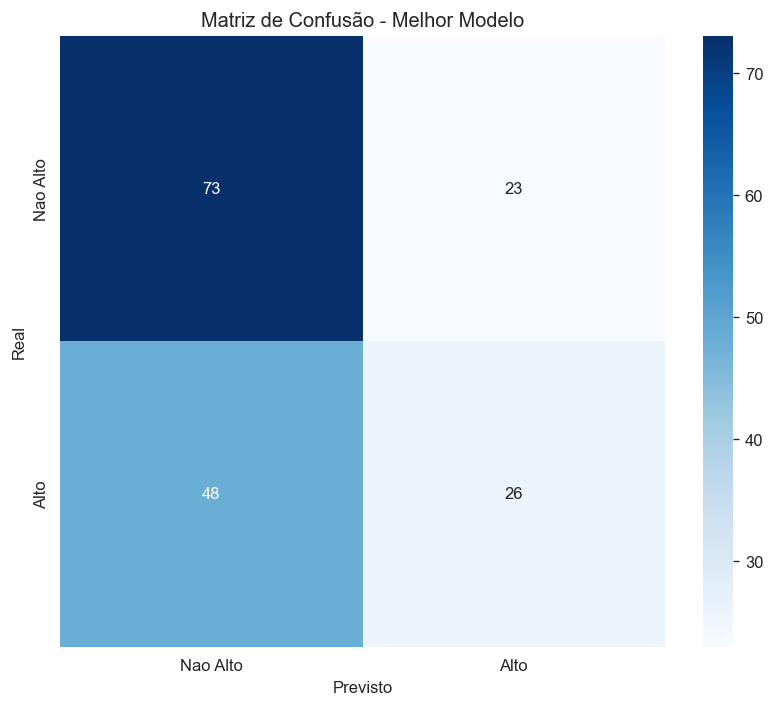

In [61]:
# Matriz de confusão e salvamento
bpred = best_model.predict(X_test_s)
cm = confusion_matrix(y_test, bpred)
plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Nao Alto','Alto'], yticklabels=['Nao Alto','Alto'])
plt.title('Matriz de Confusão - Melhor Modelo')
plt.ylabel('Real')
plt.xlabel('Previsto')
plt.tight_layout()
plt.show()

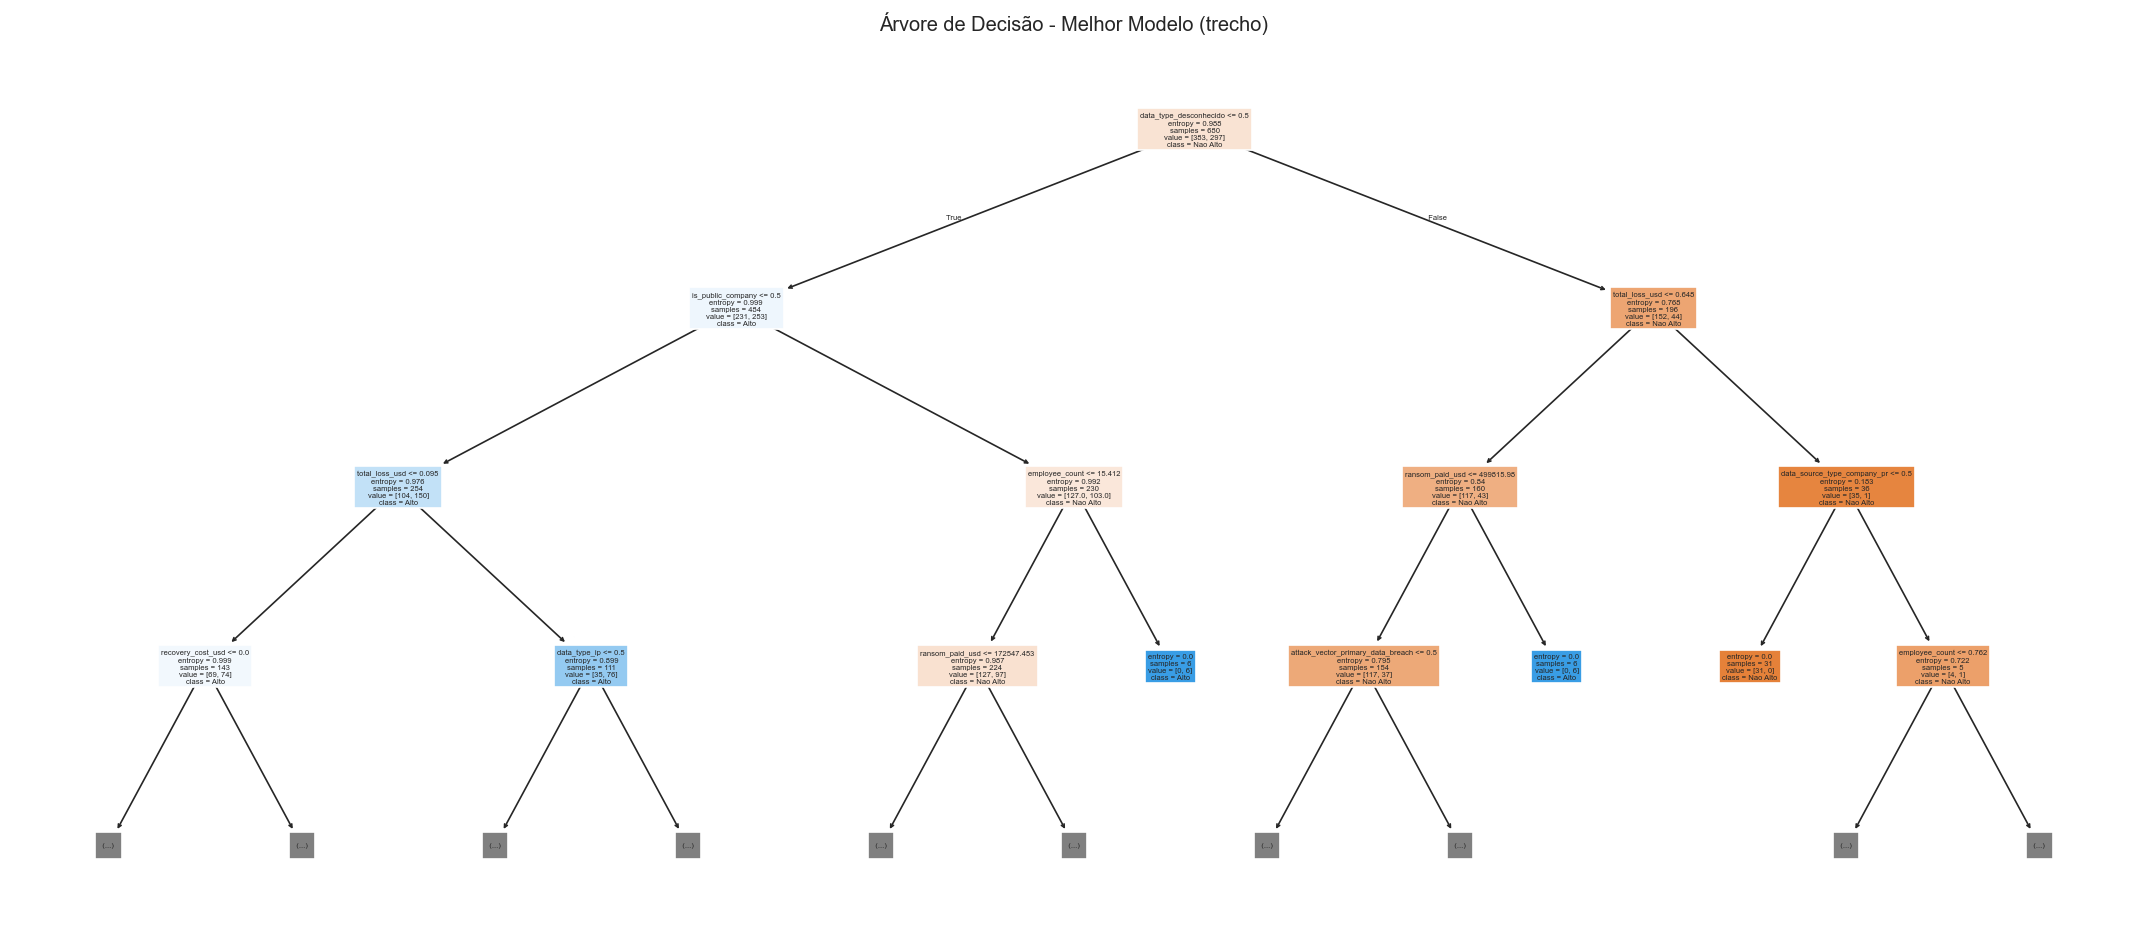

In [62]:
# Visualizar árvore (max_depth=3) e salvar
plt.figure(figsize=(18,8))
plot_tree(best_model, feature_names=features, class_names=['Nao Alto','Alto'], filled=True, max_depth=3)
plt.title('Árvore de Decisão - Melhor Modelo (trecho)')
plt.tight_layout()
plt.show()

### Comparação Prata × Ouro
Treinar o mesmo modelo (configuração do melhor) na camada Prata sem pré-processamento e comparar métricas.

In [63]:
prata_path = Path('data/silver/silver_incidents.parquet')
if not prata_path.exists():
    raise FileNotFoundError('silver_incidents.parquet nao encontrado')
df_prata = pd.read_parquet(prata_path)

num_cols_prata = df_prata.select_dtypes(include=[np.number]).columns.tolist()
feat_prata = [c for c in num_cols_prata if c not in
              [target, 'incident_id', '_is_severe_loss', '_is_significant_drop']]
print(f'Features Prata (numericas brutas): {len(feat_prata)}')

X_p = df_prata[feat_prata].fillna(df_prata[feat_prata].median())
y_p = df_prata[target]
X_tr_p, X_te_p, y_tr_p, y_te_p = train_test_split(
    X_p, y_p, test_size=0.2, random_state=42, stratify=y_p
)

cfg = dict(max_depth=best_model.max_depth, criterion=best_model.criterion, random_state=42)
model_prata = DecisionTreeClassifier(**cfg)
model_prata.fit(X_tr_p, y_tr_p)
pred_p = model_prata.predict(X_te_p)

comp = pd.DataFrame({
    'Metrica': ['Acuracia', 'Precisao', 'Recall', 'F1-score'],
    'Prata':   [round(accuracy_score(y_te_p, pred_p), 4), round(precision_score(y_te_p, pred_p, zero_division=0), 4), round(recall_score(y_te_p, pred_p, zero_division=0), 4), round(f1_score(y_te_p, pred_p, zero_division=0), 4)],
    'Ouro':    [round(accuracy_score(y_test, bpred), 4), round(precision_score(y_test, bpred, zero_division=0), 4), round(recall_score(y_test, bpred, zero_division=0), 4), round(f1_score(y_test, bpred, zero_division=0), 4)],
})
comp['Delta (Ouro - Prata)'] = (comp['Ouro'] - comp['Prata']).round(4)
display(comp)


Features Prata (numericas brutas): 4


,Metrica,Prata,Ouro,Delta (Ouro - Prata)
0,Acuracia,1.0,0.5824,-0.4176
1,Precisao,1.0,0.5306,-0.4694
2,Recall,1.0,0.3514,-0.6486
3,F1-score,1.0,0.4228,-0.5772


## Refatoração com PySpark

As células abaixo demonstram duas etapas do pipeline refatoradas com PySpark: join entre datasets, agregação por vetor de ataque e window functions (rank por setor e média móvel de perdas). Ao final é feita uma comparação de tempo de execução entre Pandas e PySpark.


In [64]:
import sys, shutil

# Configura Python correto para workers PySpark (necessario no Windows)
os.environ['PYSPARK_PYTHON'] = sys.executable
os.environ['PYSPARK_DRIVER_PYTHON'] = sys.executable

# Configura HADOOP_HOME para evitar erro de variavel nao definida
_hadoop_dir = os.path.join(os.getcwd(), '.hadoop_home')
os.makedirs(os.path.join(_hadoop_dir, 'bin'), exist_ok=True)
os.environ['HADOOP_HOME'] = _hadoop_dir
os.environ['hadoop.home.dir'] = _hadoop_dir

# Java 23 removeu SecurityManager; a flag abaixo restaura compatibilidade com Hadoop
spark = (SparkSession.builder
    .appName('CibersegurancaPipeline')
    .config('spark.driver.extraJavaOptions', '-Djava.security.manager=allow')
    .getOrCreate())
print('Spark ready:', spark.sparkContext.appName)


Spark ready: CibersegurancaPipeline


In [65]:

# Versao Pandas
t0 = time.time()
pd_inc = pd.read_csv('data/raw/incidents_master.csv')
pd_fin = pd.read_csv('data/raw/financial_impact.csv')
pd_joined = pd_inc.merge(pd_fin, on='incident_id', how='left')
pd_agg = (pd_joined
    .groupby('attack_vector_primary')
    .agg(total_incidentes=('incident_id', 'count'), media_perda_usd=('total_loss_usd', 'mean'))
    .reset_index())
t_pandas = time.time() - t0
print(f'Pandas join+agg: {t_pandas:.3f}s')

# Versao PySpark
t1 = time.time()
raw_inc = spark.read.csv('data/raw/incidents_master.csv', header=True, inferSchema=True)
raw_fin = spark.read.csv('data/raw/financial_impact.csv', header=True, inferSchema=True)

dup_cols = (set(raw_inc.columns) & set(raw_fin.columns)) - {'incident_id'}
for col in dup_cols:
    raw_fin = raw_fin.withColumnRenamed(col, f'fin_{col}')

joined = raw_inc.join(raw_fin, on='incident_id', how='left')
agg = joined.groupBy('attack_vector_primary').agg(
    F.count('incident_id').alias('total_incidentes'),
    F.mean('total_loss_usd').alias('media_perda_usd')
)
agg.show(truncate=False)

# Coletar para Pandas e salvar como arquivo Parquet (evita dependencia de winutils no Windows)
spark_out_path = 'data/gold/spark_output.parquet'
if os.path.isdir(spark_out_path):
    shutil.rmtree(spark_out_path)
joined.toPandas().to_parquet(spark_out_path, index=False)
t_spark = time.time() - t1
print(f'PySpark join+agg: {t_spark:.3f}s')

print('=== Comparacao Pandas vs PySpark ===')
print(f'Pandas : {t_pandas:.3f}s')
print(f'PySpark: {t_spark:.3f}s')
print('Nota: Para datasets pequenos (<1M linhas), o overhead do contexto Spark domina.')
print('PySpark e vantajoso a partir de GBs de dados.')


Pandas join+agg: 0.023s


+---------------------+----------------+--------------------+
|attack_vector_primary|total_incidentes|media_perda_usd     |
+---------------------+----------------+--------------------+
|apt                  |84              |7.608129263666666E7 |
|supply_chain         |58              |9.813807333518524E7 |
|ddos                 |67              |6.639258728016948E7 |
|data_breach          |123             |9.486453172437502E7 |
|ransomware           |228             |6.283857058320389E7 |
|trojan               |34              |2.3403274310937498E7|
|phishing             |147             |7.489036199015266E7 |
|malware              |79              |3.267722601319444E7 |
|backdoor             |30              |1.1234162367714287E8|
+---------------------+----------------+--------------------+



PySpark join+agg: 3.862s
=== Comparacao Pandas vs PySpark ===
Pandas : 0.023s
PySpark: 3.862s
Nota: Para datasets pequenos (<1M linhas), o overhead do contexto Spark domina.
PySpark e vantajoso a partir de GBs de dados.


In [66]:
spark_out = spark.createDataFrame(pd.read_parquet('data/gold/spark_output.parquet'))
print('Colunas em spark_output:', spark_out.columns[:6])

win_rank = Window.partitionBy('industry_primary').orderBy(F.desc('total_loss_usd'))
ranked = spark_out.withColumn('rank_perda_no_setor', F.rank().over(win_rank))

win_avg = Window.partitionBy('industry_primary').orderBy('incident_id').rowsBetween(-1, 1)
ranked = ranked.withColumn('media_movel_perda', F.avg('total_loss_usd').over(win_avg))

ranked.select('incident_id', 'industry_primary', 'total_loss_usd',
              'rank_perda_no_setor', 'media_movel_perda').show(10, truncate=False)

# Coletar para Pandas e salvar como arquivo Parquet
spark_ranked_path = 'data/gold/spark_ranked.parquet'
if os.path.isdir(spark_ranked_path):
    shutil.rmtree(spark_ranked_path)
ranked.toPandas().to_parquet(spark_ranked_path, index=False)
print('Salvo: data/gold/spark_ranked.parquet')


Colunas em spark_output: ['incident_id', 'company_name', 'company_revenue_usd', 'country_hq', 'industry_primary', 'industry_secondary']


+-------------+----------------+--------------+-------------------+--------------------+
|incident_id  |industry_primary|total_loss_usd|rank_perda_no_setor|media_movel_perda   |
+-------------+----------------+--------------+-------------------+--------------------+
|2021-1104-001|11              |4930337.16    |2                  |2699499.69          |
|2022-0123-001|11              |468662.22     |4                  |2420858.66          |
|2023-1010-001|11              |1863576.6     |3                  |2878480.5566666666  |
|2024-0523-001|11              |6303202.85    |1                  |4083389.7249999996  |
|2021-0101-001|21              |1.430087228E7 |13                 |7.9580857935E7      |
|2021-0120-001|21              |1.4486084359E8|4                  |NaN                 |
|2021-0213-002|21              |NaN           |1                  |NaN                 |
|2021-0424-001|21              |5.248817957E7 |8                  |NaN                 |
|2021-0529-001|21    

Salvo: data/gold/spark_ranked.parquet


# DATA LINEAGE — PIPELINE MEDALLION (3 FONTES)

## ORIGENS

| Arquivo | Linhas | Colunas | Tamanho |
|---------|--------|---------|--------|
| incidents_master.csv | 850 | 32 | 438 KB |
| market_impact.csv | 358 | 31 | 109 KB |
| financial_impact.csv | 778 | 19 | 170 KB |

---

## CAMADA BRONZE

| Dataset | Linhas | Colunas | Saída |
|---------|--------|---------|-------|
| bronze_incidents | 850 | 36 | Parquet |
| bronze_market | 358 | 35 | Parquet |
| bronze_financials | 778 | 23 | Parquet |

**Transformações:** conversão de tipos (datas, numéricos), adição de metadados (`_ingestion_timestamp`, `sha256_hash`, `record_count`), relatórios de qualidade por dataset.

---

## CAMADA SILVER

| Dataset | Linhas | Colunas | Saída |
|---------|--------|---------|-------|
| silver_incidents | 850 | 29 | Parquet |
| silver_market | 358 | 32 | Parquet |
| silver_financials | 778 | 20 | Parquet |

**Transformações:**
- Remoção de duplicatas e colunas sem valor preditivo
- Padronização categórica (`lower().strip()`)
- Imputação semântica de nulos (ex.: `days_to_price_recovery` nulo → -1)
- Remoção de leakage ALTO: `quality_score`, `quality_grade`, `confidence_tier`, `review_flag`
- Labels criadas: `_is_high_impact` | `_is_severe_loss` | `_is_significant_drop`

---

## EDA ORIENTADA A HIPÓTESES

| Hipótese | Resultado |
|----------|-----------|
| H1: APT/ransomware concentram maior prejuízo financeiro | Confirmada |
| H2: Setor financeiro tem recuperação de preço mais lenta | Parcialmente confirmada |
| H3: Proporção de incidentes graves aumentou em 2021–2025 | Parcialmente confirmada |

---

## CAMADA OURO

| Dataset | Linhas | Colunas | Saída |
|---------|--------|---------|-------|
| gold_dataset (ML-Ready) | 850 | 79 | Parquet |
| gold_incidents (pré-merge) | 850 | 51 | Parquet |
| gold_market | 358 | 29 | Parquet |
| gold_financials | 778 | 17 | Parquet |

**Transformações:**
- Feature engineering: `days_to_discovery`, `days_to_disclosure` (latência de detecção/divulgação)
- Remoção de leakage ALTO: `data_compromised_records` e `downtime_hours` (fontes diretas do target)
- Left join `incidents` + `financials` por `incident_id` → 72 nulos tratados por imputer
- Outlier 1: `company_revenue_usd` → Winsorização IQR (cap = Q3 + 3×IQR, fit no treino)
- Outlier 2: `total_loss_usd` → transformação log1p (skewness > 5)
- OrdinalEncoder: `attribution_confidence` (5 níveis de certeza)
- OneHotEncoder: `attack_vector_primary`, `data_type`, `data_source_type` e outras nominais
- SimpleImputer(median): colunas financeiras numéricas — Estratégia 1
- SimpleImputer(constant='nao_disponivel'): categóricas financeiras — Estratégia 2
- RobustScaler: 7 colunas numéricas contínuas (fit apenas no treino)
- Split: 680 treino / 170 teste (80/20, stratify=`_is_high_impact`)

---

## MODELAGEM ML

| Modelo | Configuração | Dataset |
|--------|-------------|--------|
| DT_v1 | max_depth=5, criterion=gini | Ouro |
| DT_v2 | max_depth=10, criterion=entropy | Ouro |

Comparação Prata × Ouro demonstra que o pré-processamento elimina o leakage implícito presente nas features brutas da camada Prata.

---

## REFATORAÇÃO PYSPARK

| Etapa | Operação | Saída |
|-------|----------|-------|
| 1 | Join `incidents` + `financials` + groupBy por vetor de ataque | spark_output.parquet |
| 2 | Window functions: rank por setor + média móvel de perdas | spark_ranked.parquet |

---

## FLUXO COMPLETO

```
Raw CSV
  └─► Bronze  (Parquet + metadados + qualidade)
        └─► Silver  (limpeza + labels + anti-leakage)
              ├─► EDA  (hipóteses H1 / H2 / H3)
              └─► Ouro  (encoding + scaling + fit/transform)
                    ├─► ML-Ready  (Decision Trees + comparação Prata x Ouro)
                    └─► PySpark  (join + groupBy + window functions)
```

**Targets:** `_is_high_impact` (43,6%) | `_is_severe_loss` (50%) | `_is_significant_drop` (8,1%)
